# Model 2 — Dataset Inspection & Data Inventory

Before cleaning or building the vessel-selection model, we will inspect the core datasets and understand their structure, columns, missing values, duplicates, and key categories.

**Core datasets:**
1. Cargo Master
2. Port Master
3. Route Master
4. Vessel Master

This step will help us decide which variables are suitable for Model 2.

In [2]:
from pathlib import Path
import pandas as pd

# ============================================================
# MODEL 2 — DATASET INSPECTION
# ============================================================

# Project directory
PROJECT_DIR = (
    Path.home()
    / "OneDrive"
    / "Desktop"
    / "Freight rate forecasting ML project"
)

# Dataset directory
DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "raw"
    / "Official_datasets"
    / "Official_datasets"
)

print("Dataset Directory:")
print(DATA_DIR)
print("\nDirectory Exists:", DATA_DIR.exists())

# ============================================================
# 1. Dataset paths
# ============================================================

file_paths = {
    "Cargo Master":
        DATA_DIR / "cargo dataset" / "cargo_master.csv",

    "Port Master":
        DATA_DIR / "PORT_Master Dataset" / "port_master_cleaned.csv",

    "Route Master":
        DATA_DIR / "Route Master Dataset" / "route_master_final.csv",

    "Vessel Master":
        DATA_DIR / "Vessel_master dataset" / "vessel_master_cleaned.csv"
}

# Check files
print("\n" + "=" * 80)
print("FILE CHECK")
print("=" * 80)

for name, path in file_paths.items():
    print(f"{name}: {path.exists()}")

# ============================================================
# 2. Load datasets
# ============================================================

datasets = {}

for name, path in file_paths.items():
    datasets[name] = pd.read_csv(path)

# ============================================================
# 3. Basic dataset information
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{name.upper()}")
    print("=" * 80)

    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]:,}")

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

# ============================================================
# 4. Missing values
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{name} — MISSING VALUES")
    print("=" * 80)

    missing = pd.DataFrame({
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (
            df.isnull().sum() / len(df) * 100
        ).round(2)
    })

    missing = missing[missing["Missing_Count"] > 0]

    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing)

# ============================================================
# 5. Duplicate records
# ============================================================

print("\n" + "=" * 80)
print("DUPLICATE RECORDS")
print("=" * 80)

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum():,}")

# ============================================================
# 6. Key categories
# ============================================================

cargo_df = datasets["Cargo Master"]
route_df = datasets["Route Master"]
vessel_df = datasets["Vessel Master"]

print("\n" + "=" * 80)
print("KEY CATEGORIES")
print("=" * 80)

print("\nCargo Types:")
print(cargo_df["cargo_type"].value_counts())

print("\nOrigin Countries:")
print(cargo_df["origin_country"].value_counts())

print("\nDestination Countries:")
print(cargo_df["destination_country"].value_counts())

print("\nTrade Flow:")
print(cargo_df["trade_flow"].value_counts())

print("\nVessel Classes:")
print(vessel_df["vessel_class"].value_counts())

print("\nIndian Reference Ports:")
print(route_df["reference_port"].value_counts())

print("\nConnected Overseas Countries:")
print(route_df["connected_port_country"].value_counts())

# ============================================================
# 7. Numerical summaries
# ============================================================

print("\n" + "=" * 80)
print("NUMERICAL SUMMARIES")
print("=" * 80)

print("\nCargo Quantity (MT):")
print(cargo_df["cargo_quantity_mt"].describe())

print("\nVessel Deadweight (DWT):")
print(vessel_df["deadweight"].describe())

print("\nVessel Draft (m):")
print(vessel_df["ship_draught"].describe())

print("\nRoute Distance (NM):")
print(route_df["route_distance_nm"].describe())

# ============================================================
# 8. Preview datasets
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{name} — FIRST 5 ROWS")
    print("=" * 80)

    display(df.head())

Dataset Directory:
C:\Users\pradi\OneDrive\Desktop\Freight rate forecasting ML project\data\raw\Official_datasets\Official_datasets

Directory Exists: True

FILE CHECK
Cargo Master: True
Port Master: True
Route Master: True
Vessel Master: True

CARGO MASTER
Rows    : 384
Columns : 12

Columns:
['cargo_record_id', 'cargo_id', 'year', 'cargo_type', 'cargo_subtype', 'origin_country', 'destination_country', 'trade_flow', 'commodity_code', 'cargo_quantity_mt', 'trade_value_usd', 'source']

Data Types:
cargo_record_id          int64
cargo_id                 int64
year                     int64
cargo_type                 str
cargo_subtype              str
origin_country             str
destination_country        str
trade_flow                 str
commodity_code           int64
cargo_quantity_mt      float64
trade_value_usd        float64
source                     str
dtype: object

PORT MASTER
Rows    : 3,805
Columns : 44

Columns:
['wpi_number', 'region_name', 'port_name', 'alternate_port_n

,cargo_record_id,cargo_id,year,cargo_type,cargo_subtype,origin_country,destination_country,trade_flow,commodity_code,cargo_quantity_mt,trade_value_usd,source
0,1,1,2019,Iron Ore,Iron ores and concentrates; non-agglomerated,World,India,Import,260111,2.075430e+06,1.833594e+08,UN Comtrade
1,2,2,2019,Iron Ore,Iron ores and concentrates; agglomerated (excl...,World,India,Import,260112,5.380762e+04,6.289990e+06,UN Comtrade
2,3,3,2019,Iron Ore,Iron ores and concentrates; non-agglomerated,India,World,Export,260111,1.835411e+07,1.020338e+09,UN Comtrade
3,4,4,2019,Iron Ore,Iron ores and concentrates; agglomerated (excl...,India,World,Export,260112,1.285651e+07,1.337903e+09,UN Comtrade
4,5,5,2020,Iron Ore,Iron ores and concentrates; non-agglomerated,World,India,Import,260111,3.385626e+05,4.069009e+07,UN Comtrade



Port Master — FIRST 5 ROWS


,wpi_number,region_name,port_name,alternate_port_name,unlocode,country_code,world_water_body,tidal_range_m,entrance_width_m,channel_depth_m,...,facilities_anchorage,facilities_solid_bulk,facilities_liquid_bulk,facilities_container,facilities_breakbulk,facilities_oil_terminal,facilities_lng_terminal,facilities_other,latitude,longitude
0,8225.0,United States E Coast -- 6585,Annapolis,NaN,USANP,UNITED STATES,North Atlantic Ocean,0.3,NaN,4.9,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,38.983333,-76.483333
1,8210.0,United States E Coast -- 6585,Baltimore,NaN,USBAL,UNITED STATES,North Atlantic Ocean,0.3,NaN,14.0,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,39.266667,-76.583333
2,8130.0,United States E Coast -- 6585,Camden,NaN,USCDE,UNITED STATES,North Atlantic Ocean,1.8,NaN,11.0,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,39.950000,-75.133333
3,8080.0,United States E Coast -- 6585,Chester,NaN,USCHT,UNITED STATES,North Atlantic Ocean,1.8,NaN,11.0,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,39.850000,-75.350000
4,7950.0,United States E Coast -- 6585,Maurer,NaN,NaN,UNITED STATES,North Atlantic Ocean,1.5,NaN,11.0,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,40.533333,-74.250000



Route Master — FIRST 5 ROWS


,reference_port,reference_port_country,connected_port,connected_port_country,direction,connection_rank,reference_port_locode,connected_port_locode,reference_nga_unlocode,connected_nga_unlocode,...,route_distance_nm,route_distance_km,distance_source,distance_method,reference_max_draft_m,connected_max_draft_m,reference_max_length_m,connected_max_length_m,reference_max_beam_m,connected_max_beam_m
0,Paradip,India,Hay Point,Australia,upstream,1,IN PRT,AU HPT,INPPT,AUHPT,...,4662.6,8635.1,Estimated,Geodesic distance × 1.05 maritime detour factor,14.5,19.6,295.0,300.0,46.0,50.0
1,Paradip,India,Mina Saqr,United Arab Emirates,upstream,2,IN PRT,AE MSA,INPPT,AEMSA,...,1807.8,3348.0,Estimated,Geodesic distance × 1.05 maritime detour factor,14.5,12.2,295.0,300.0,46.0,50.0
2,Paradip,India,Richards Bay,South Africa,upstream,3,IN PRT,ZA RCB,INPPT,ZARCB,...,4537.6,8403.6,Estimated,Geodesic distance × 1.05 maritime detour factor,14.5,17.5,295.0,300.0,46.0,50.0
3,Paradip,India,Haldia,India,upstream,4,IN PRT,IN HAL,INPPT,INHAL,...,137.6,254.8,Estimated,Geodesic distance × 1.05 maritime detour factor,14.5,8.5,295.0,177.0,46.0,44.0
4,Paradip,India,Gladstone,Australia,upstream,5,IN PRT,AU GLT,INPPT,AUGLT,...,4841.4,8966.3,Estimated,Geodesic distance × 1.05 maritime detour factor,14.5,17.9,295.0,320.0,46.0,55.0



Vessel Master — FIRST 5 ROWS


,imo,mmsi,ship_name,ship_type,vessel_class,deadweight,gross_tonnage,ship_draught,length_m,beam_m,...,builder,build_location,engine_power_kw,ship_draught_missing,length_m_missing,beam_m_missing,draft_outlier_flag,length_outlier_flag,beam_outlier_flag,technical_data_complete
0,5102865,316002501.0,MICHIPICOTEN,Self Discharging Bulk Carrier,Handysize,23491.0,15366.0,8.01,212.0,21.0,...,NaN,NaN,NaN,0,0,0,0,0,0,1
1,5103974,316001838.0,CEDARGLEN,Bulk Carrier,Handysize,28591.0,18531.0,8.40,NaN,NaN,...,NaN,NaN,NaN,0,1,1,0,0,0,0
2,5105831,316607241.0,OJIBWAY,Bulk Carrier,Handysize,18602.0,12296.0,7.59,NaN,NaN,...,NaN,NaN,NaN,0,1,1,0,0,0,0
3,5128467,316004940.0,MISSISSAGI,Self Discharging Bulk Carrier,Handysize,15787.0,10588.0,7.47,189.0,18.0,...,Great Lakes Engineering Works,NaN,NaN,0,0,0,0,0,0,1
4,5169124,316001702.0,JAMES NORRIS,Self Discharging Bulk Carrier,Handysize,18583.0,12962.0,7.40,NaN,NaN,...,NaN,NaN,NaN,0,1,1,0,0,0,0


# Model 2 — Define Relevant Trade Scope

Model 2 focuses on dry-bulk cargo transported from overseas origins
to Indian East Coast ports.

We will identify:
- Import cargo records
- Indian East Coast ports
- Overseas connected ports
- Relevant vessel classes

This filtered data will form the foundation for Model 2 preprocessing.

In [3]:
# ============================================================
# MODEL 2 — DEFINE RELEVANT TRADE SCOPE
# ============================================================

cargo_df = datasets["Cargo Master"].copy()
route_df = datasets["Route Master"].copy()
vessel_df = datasets["Vessel Master"].copy()

# ------------------------------------------------------------
# 1. Keep import cargo entering India
# ------------------------------------------------------------

import_cargo = cargo_df[
    (cargo_df["trade_flow"] == "Import") &
    (cargo_df["destination_country"] == "India")
].copy()

print("Import Cargo Records:", len(import_cargo))

# ------------------------------------------------------------
# 2. Define Indian East Coast ports
# ------------------------------------------------------------

east_coast_ports = [
    "Kolkata",
    "Haldia",
    "Paradip",
    "Dhamra Port",
    "Gopalpur",
    "Visakhapatnam",
    "Kakinada",
    "Krishnapatnam Port",
    "Chennai (Madras)",
    "Kamarajar Port",
    "Kattupalli",
    "Karaikal",
    "Tuticorin"
]

# Filter routes where Indian reference port is East Coast
east_coast_routes = route_df[
    route_df["reference_port"].isin(east_coast_ports)
].copy()

print("East Coast Route Records:", len(east_coast_routes))

# ------------------------------------------------------------
# 3. Keep only overseas connected ports
# ------------------------------------------------------------

overseas_routes = east_coast_routes[
    east_coast_routes["connected_port_country"] != "India"
].copy()

print("Overseas → East Coast Routes:", len(overseas_routes))

# ------------------------------------------------------------
# 4. Relevant vessel classes
# ------------------------------------------------------------

bulk_vessel_classes = [
    "Handysize",
    "Supramax",
    "Panamax",
    "Capesize"
]

bulk_vessels = vessel_df[
    vessel_df["vessel_class"].isin(bulk_vessel_classes)
].copy()

print("Relevant Vessels:", len(bulk_vessels))

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EAST COAST PORTS FOUND")
print("=" * 70)

print(
    east_coast_routes["reference_port"]
    .value_counts()
)

print("\n" + "=" * 70)
print("OVERSEAS ORIGIN COUNTRIES")
print("=" * 70)

print(
    overseas_routes["connected_port_country"]
    .value_counts()
)

print("\n" + "=" * 70)
print("IMPORT CARGO TYPES")
print("=" * 70)

print(
    import_cargo["cargo_type"]
    .value_counts()
)

print("\n" + "=" * 70)
print("VESSEL CLASSES")
print("=" * 70)

print(
    bulk_vessels["vessel_class"]
    .value_counts()
)

Import Cargo Records: 188
East Coast Route Records: 130
Overseas → East Coast Routes: 66
Relevant Vessels: 2991

EAST COAST PORTS FOUND
reference_port
Paradip               10
Visakhapatnam         10
Dhamra Port           10
Krishnapatnam Port    10
Kakinada              10
Kamarajar Port        10
Haldia                10
Kolkata               10
Tuticorin             10
Chennai (Madras)      10
Gopalpur              10
Karaikal              10
Kattupalli            10
Name: count, dtype: int64

OVERSEAS ORIGIN COUNTRIES
connected_port_country
Sri Lanka               11
Australia               10
Singapore                8
China                    7
United Arab Emirates     6
South Africa             6
Indonesia                6
Malaysia                 6
Brazil                   3
Canada                   1
Côte d'Ivoire            1
Iraq                     1
Name: count, dtype: int64

IMPORT CARGO TYPES
cargo_type
Grain             48
Fertilizer        35
Cement/Clinker    35
Coal

# Model 2 — Port Constraint Mapping

For vessel selection, the destination port must be able to accommodate
the selected vessel.

We will map the selected Indian East Coast ports to the Port Master
dataset and extract important port constraints such as:

- Maximum vessel draft
- Channel depth
- Anchorage depth
- Cargo pier depth

These constraints will later be used to determine vessel feasibility.

In [4]:
# ============================================================
# MODEL 2 — PORT CONSTRAINT MAPPING
# ============================================================

port_df = datasets["Port Master"].copy()

# ------------------------------------------------------------
# 1. Select required port columns
# ------------------------------------------------------------

port_constraints = port_df[
    [
        "port_name",
        "unlocode",
        "country_code",
        "channel_depth_m",
        "anchorage_depth_m",
        "cargo_pier_depth_m",
        "max_vessel_draft_m",
        "latitude",
        "longitude"
    ]
].copy()

# ------------------------------------------------------------
# 2. Map our East Coast ports
# ------------------------------------------------------------

east_coast_port_constraints = port_constraints[
    port_constraints["port_name"].isin(east_coast_ports)
].copy()

# ------------------------------------------------------------
# 3. Display mapping results
# ------------------------------------------------------------

print("=" * 80)
print("EAST COAST PORT CONSTRAINTS")
print("=" * 80)

display(
    east_coast_port_constraints.sort_values("port_name")
)

# ------------------------------------------------------------
# 4. Check which ports were not matched
# ------------------------------------------------------------

matched_ports = set(
    east_coast_port_constraints["port_name"]
)

unmatched_ports = [
    port for port in east_coast_ports
    if port not in matched_ports
]

print("\n" + "=" * 80)
print("PORT MATCHING CHECK")
print("=" * 80)

print("Total East Coast Ports :", len(east_coast_ports))
print("Matched Ports          :", len(matched_ports))
print("Unmatched Ports        :", len(unmatched_ports))

if unmatched_ports:
    print("\nUnmatched Ports:")
    print(unmatched_ports)
else:
    print("\nAll East Coast ports successfully matched.")

# ------------------------------------------------------------
# 5. Missing draft information
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PORT DRAFT DATA QUALITY")
print("=" * 80)

print(
    east_coast_port_constraints[
        ["port_name", "max_vessel_draft_m", "channel_depth_m"]
    ].sort_values("port_name")
)

print("\nMissing Maximum Vessel Draft:")
print(
    east_coast_port_constraints["max_vessel_draft_m"]
    .isna()
    .sum()
)

EAST COAST PORT CONSTRAINTS


,port_name,unlocode,country_code,channel_depth_m,anchorage_depth_m,cargo_pier_depth_m,max_vessel_draft_m,latitude,longitude
3749,Chennai (Madras),INMAA,INDIA,18.6,15.5,15.0,16.5,13.100000,80.300000
1040,Gopalpur,INGPR,INDIA,NaN,NaN,15.0,13.5,19.301944,84.966667
1041,Kamarajar Port,INENR,INDIA,15.5,15.5,15.0,15.0,13.261389,80.342500
1042,Paradip,INPPT,INDIA,12.5,9.4,17.1,14.5,20.266667,86.683333
1020,Tuticorin,INTUT,INDIA,12.5,15.5,14.1,14.2,8.800000,78.166667



PORT MATCHING CHECK
Total East Coast Ports : 13
Matched Ports          : 5
Unmatched Ports        : 8

Unmatched Ports:
['Kolkata', 'Haldia', 'Dhamra Port', 'Visakhapatnam', 'Kakinada', 'Krishnapatnam Port', 'Kattupalli', 'Karaikal']

PORT DRAFT DATA QUALITY
             port_name  max_vessel_draft_m  channel_depth_m
3749  Chennai (Madras)                16.5             18.6
1040          Gopalpur                13.5              NaN
1041    Kamarajar Port                15.0             15.5
1042           Paradip                14.5             12.5
1020         Tuticorin                14.2             12.5

Missing Maximum Vessel Draft:
0


In [5]:
# ============================================================
# MODEL 2 — PORT NAME MATCHING
# ============================================================

from difflib import get_close_matches

all_port_names = (
    port_df["port_name"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("=" * 80)
print("POSSIBLE PORT NAME MATCHES")
print("=" * 80)

for port in unmatched_ports:

    matches = get_close_matches(
        port,
        all_port_names,
        n=10,
        cutoff=0.4
    )

    print(f"\n{port}")
    print("-" * 50)

    if matches:
        for match in matches:
            print(match)
    else:
        print("No close match found")

POSSIBLE PORT NAME MATCHES

Kolkata
--------------------------------------------------
Aokata
Kotka
Kalamata
Tobata
Hakata
Metlakatla
Wolgast
Toliara
Selaata
Korcula

Haldia
--------------------------------------------------
Halifax
Haifa
Haldia Port
Salina
Mahdia
Hazira
Hamina
Halden
Hadera
Dalian

Dhamra Port
--------------------------------------------------
Kamarajar Port
Dhamra
Karaikal Port
Haldia Port
Al Jazeera Port
Bird Port
Shepard Point
Trap Point
Thamesport
Onahama Ko

Visakhapatnam
--------------------------------------------------
Vishakhapatnam
Krishnapatnam
Nagappattinam
Machilipatnam
Mahajanga
Yahata
Hakata
Balikpapan
Zaandam
Paranam

Kakinada
--------------------------------------------------
Kakinada Bay
Kanda
Kandla
Kanatak
Hibikinada
Cabinda
Kaliningrad
Kyleakin
Klaipeda
Kaukauna

Krishnapatnam Port
--------------------------------------------------
Krishnapatnam
Vishakhapatnam
Karaikal Port
King Fahd Port
Kattupalli Port
Kribi Deep Sea Port
Western Port
Nasipit Po

In [6]:
# ============================================================
# MODEL 2 — VERIFIED PORT NAME MAPPING
# ============================================================

port_name_mapping = {
    "Kolkata": None,                  # No reliable match found
    "Haldia": "Haldia Port",
    "Paradip": "Paradip",
    "Dhamra Port": "Dhamra",
    "Gopalpur": "Gopalpur",
    "Visakhapatnam": "Vishakhapatnam",
    "Kakinada": "Kakinada Bay",
    "Krishnapatnam Port": "Krishnapatnam",
    "Chennai (Madras)": "Chennai (Madras)",
    "Kamarajar Port": "Kamarajar Port",
    "Kattupalli": "Kattupalli Port",
    "Karaikal": "Karaikal Port",
    "Tuticorin": "Tuticorin"
}

# Create mapping table
port_mapping_df = pd.DataFrame(
    list(port_name_mapping.items()),
    columns=["Project_Port_Name", "Port_Master_Name"]
)

display(port_mapping_df)

,Project_Port_Name,Port_Master_Name
0,Kolkata,NaN
1,Haldia,Haldia Port
2,Paradip,Paradip
3,Dhamra Port,Dhamra
4,Gopalpur,Gopalpur
5,Visakhapatnam,Vishakhapatnam
6,Kakinada,Kakinada Bay
7,Krishnapatnam Port,Krishnapatnam
8,Chennai (Madras),Chennai (Madras)
9,Kamarajar Port,Kamarajar Port


In [7]:
# ============================================================
# MODEL 2 — BUILD PORT CONSTRAINT DATASET
# ============================================================

# Remove unresolved ports
valid_mapping = port_mapping_df.dropna(
    subset=["Port_Master_Name"]
).copy()

# Merge project port names with Port Master
port_constraints_final = valid_mapping.merge(
    port_df,
    left_on="Port_Master_Name",
    right_on="port_name",
    how="left"
)

# Keep only important columns
port_constraints_final = port_constraints_final[
    [
        "Project_Port_Name",
        "Port_Master_Name",
        "unlocode",
        "channel_depth_m",
        "anchorage_depth_m",
        "cargo_pier_depth_m",
        "max_vessel_draft_m",
        "latitude",
        "longitude"
    ]
].copy()

# Display final dataset
print("=" * 80)
print("FINAL EAST COAST PORT CONSTRAINT DATASET")
print("=" * 80)

display(
    port_constraints_final.sort_values("Project_Port_Name")
)

# Check missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

print(port_constraints_final.isnull().sum())

# Basic statistics
print("\n" + "=" * 80)
print("PORT DRAFT SUMMARY")
print("=" * 80)

print(
    port_constraints_final["max_vessel_draft_m"].describe()
)

FINAL EAST COAST PORT CONSTRAINT DATASET


,Project_Port_Name,Port_Master_Name,unlocode,channel_depth_m,anchorage_depth_m,cargo_pier_depth_m,max_vessel_draft_m,latitude,longitude
7,Chennai (Madras),Chennai (Madras),INMAA,18.6,15.5,15.0,16.5,13.100000,80.300000
2,Dhamra Port,Dhamra,INDMQ,17.0,NaN,19.0,19.0,20.816667,86.966667
3,Gopalpur,Gopalpur,INGPR,NaN,NaN,15.0,13.5,19.301944,84.966667
0,Haldia,Haldia Port,INHAL,7.9,11.0,12.5,8.5,22.016667,88.083333
5,Kakinada,Kakinada Bay,INKAK,NaN,9.4,NaN,13.0,17.000000,82.316667
8,Kamarajar Port,Kamarajar Port,INENR,15.5,15.5,15.0,15.0,13.261389,80.342500
10,Karaikal,Karaikal Port,INKRK,15.5,11.0,14.5,14.0,10.833333,79.866667
9,Kattupalli,Kattupalli Port,INKRI,14.0,NaN,14.0,NaN,13.306944,80.352222
6,Krishnapatnam Port,Krishnapatnam,INKRI,NaN,NaN,18.7,19.5,14.250000,80.133333
1,Paradip,Paradip,INPPT,12.5,9.4,17.1,14.5,20.266667,86.683333



MISSING VALUES
Project_Port_Name     0
Port_Master_Name      0
unlocode              0
channel_depth_m       3
anchorage_depth_m     4
cargo_pier_depth_m    1
max_vessel_draft_m    1
latitude              0
longitude             0
dtype: int64

PORT DRAFT SUMMARY
count    11.000000
mean     15.072727
std       3.137544
min       8.500000
25%      13.750000
50%      14.500000
75%      17.300000
max      19.500000
Name: max_vessel_draft_m, dtype: float64


# Model 2 — Vessel Feasibility Rules

A vessel is considered feasible when it satisfies the physical
requirements of the cargo and destination port.

Rules:

1. Vessel deadweight must be sufficient for the cargo quantity.
2. Vessel draft must not exceed the destination port's maximum
   allowable vessel draft.
3. Only the four dry-bulk vessel classes are considered:
   Handysize, Supramax, Panamax, and Capesize.

These rules will later be used to generate the rule-based
"Best Vessel" labels for Model 2.

In [8]:
# ============================================================
# MODEL 2 — VESSEL FEASIBILITY TEST
# ============================================================

# Work with vessels having the essential information
vessels_feasibility = bulk_vessels[
    [
        "imo",
        "vessel_class",
        "deadweight",
        "ship_draught"
    ]
].copy()

# Remove vessels without DWT or draft
vessels_feasibility = vessels_feasibility.dropna(
    subset=["deadweight", "ship_draught"]
)

# ------------------------------------------------------------
# Test cargo
# ------------------------------------------------------------

test_cargo_quantity = 70000  # metric tons
test_port = "Paradip"

# Get port draft limit
port_limit = port_constraints_final.loc[
    port_constraints_final["Project_Port_Name"] == test_port,
    "max_vessel_draft_m"
].iloc[0]

# ------------------------------------------------------------
# Apply feasibility rules
# ------------------------------------------------------------

feasible_vessels = vessels_feasibility[
    (vessels_feasibility["deadweight"] >= test_cargo_quantity) &
    (vessels_feasibility["ship_draught"] <= port_limit)
].copy()

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("=" * 80)
print("VESSEL FEASIBILITY TEST")
print("=" * 80)

print(f"Test Cargo Quantity : {test_cargo_quantity:,} MT")
print(f"Destination Port    : {test_port}")
print(f"Maximum Port Draft  : {port_limit} m")

print("\nTotal Vessels Tested :", len(vessels_feasibility))
print("Feasible Vessels     :", len(feasible_vessels))

print("\nFeasible Vessels by Class:")
print(
    feasible_vessels["vessel_class"].value_counts()
)

print("\nSample Feasible Vessels:")
display(
    feasible_vessels.head(10)
)

VESSEL FEASIBILITY TEST
Test Cargo Quantity : 70,000 MT
Destination Port    : Paradip
Maximum Port Draft  : 14.5 m

Total Vessels Tested : 2614
Feasible Vessels     : 517

Feasible Vessels by Class:
vessel_class
Panamax     494
Capesize     23
Name: count, dtype: int64

Sample Feasible Vessels:


,imo,vessel_class,deadweight,ship_draught
115,7915632,Panamax,98358.0,11.410
125,7926148,Panamax,75569.0,13.500
127,7926174,Panamax,75598.0,7.800
141,8007793,Panamax,73609.0,14.479
147,8009571,Panamax,74517.0,13.430
155,8015661,Panamax,70912.0,13.482
159,8022511,Panamax,78394.0,6.880
161,8023656,Panamax,71242.0,13.490
190,8105492,Panamax,74973.0,13.920
199,8110198,Panamax,94994.0,12.600


# Model 2 — Freight Cost Proxy

Route-specific charter rates are not available in the project dataset.
Therefore, a comparative freight cost proxy is constructed using vessel-class
market earnings from KOBC and route distance.

The proxy is used for comparing feasible vessel classes and is not treated
as an actual charter quotation.

In [13]:
# ---------------------------------------------------------
# LOAD KOBC DATA
# ---------------------------------------------------------

kobc_df = pd.read_excel(
    kobc_path,
    header=1
)

# Standardize column names
kobc_df.columns = (
    kobc_df.columns
    .str.strip()
    .str.upper()
)

# Convert date
kobc_df["DATE"] = pd.to_datetime(
    kobc_df["DATE"],
    errors="coerce"
)

# Convert market-rate columns to numeric
rate_columns = [
    "KDCI",
    "CAPE",
    "PANAMAX",
    "SUPRAMAX",
    "HANDY"
]

for col in rate_columns:
    kobc_df[col] = pd.to_numeric(
        kobc_df[col],
        errors="coerce"
    )

# Keep only required columns
kobc_rates = kobc_df[
    ["DATE", "KDCI", "CAPE", "PANAMAX", "SUPRAMAX", "HANDY"]
].copy()

# ---------------------------------------------------------
# DATA CHECK
# ---------------------------------------------------------

print("=" * 70)
print("KOBC DRY BULK MARKET DATA")
print("=" * 70)

print("Rows:", len(kobc_rates))
print("Columns:", kobc_rates.columns.tolist())

print(
    "Date range:",
    kobc_rates["DATE"].min().date(),
    "to",
    kobc_rates["DATE"].max().date()
)

print("\nMissing values:")
print(kobc_rates.isna().sum())

print("\nSample data:")
display(kobc_rates.head())

KOBC DRY BULK MARKET DATA
Rows: 2602
Columns: ['DATE', 'KDCI', 'CAPE', 'PANAMAX', 'SUPRAMAX', 'HANDY']
Date range: 2016-01-04 to 2026-10-08

Missing values:
DATE        0
KDCI        0
CAPE        0
PANAMAX     0
SUPRAMAX    0
HANDY       0
dtype: int64

Sample data:


,DATE,KDCI,CAPE,PANAMAX,SUPRAMAX,HANDY
0,2026-10-08,28913,45822,22607,22410,16614
1,2026-10-07,28609,45323,22445,22101,16486
2,2026-10-06,28941,46642,22416,21936,16431
3,2026-10-02,29659,48847,22489,22040,16459
4,2026-10-01,29515,48038,22592,22237,16549


# Model 2 — Vessel-Class Market Rate Mapping

KOBC provides daily dry-bulk market earnings for four vessel classes:
Capesize, Panamax, Supramax, and Handysize.

The vessel-class rates will be mapped to the corresponding vessel classes
in the Vessel Master dataset so that market earnings can be incorporated
into the comparative freight cost proxy.

In [14]:
# ---------------------------------------------------------
# CONVERT KOBC DATA FROM WIDE TO LONG FORMAT
# ---------------------------------------------------------

kobc_long = kobc_rates.melt(
    id_vars=["DATE"],
    value_vars=["CAPE", "PANAMAX", "SUPRAMAX", "HANDY"],
    var_name="KOBC_CLASS",
    value_name="MARKET_EARNINGS_USD_DAY"
)

# Map KOBC names to Vessel Master class names
class_mapping = {
    "CAPE": "Capesize",
    "PANAMAX": "Panamax",
    "SUPRAMAX": "Supramax",
    "HANDY": "Handysize"
}

kobc_long["vessel_class"] = kobc_long["KOBC_CLASS"].map(
    class_mapping
)

# Keep required columns
kobc_long = kobc_long[
    ["DATE", "vessel_class", "MARKET_EARNINGS_USD_DAY"]
].copy()

# Sort by date and vessel class
kobc_long = kobc_long.sort_values(
    ["DATE", "vessel_class"]
).reset_index(drop=True)

print("=" * 70)
print("KOBC VESSEL-CLASS MARKET RATE TABLE")
print("=" * 70)

print("Rows:", len(kobc_long))
print("Vessel classes:", kobc_long["vessel_class"].unique())

print("\nMissing values:")
print(kobc_long.isna().sum())

print("\nSample:")
display(kobc_long.head(12))

KOBC VESSEL-CLASS MARKET RATE TABLE
Rows: 10408
Vessel classes: <ArrowStringArray>
['Capesize', 'Handysize', 'Panamax', 'Supramax']
Length: 4, dtype: str

Missing values:
DATE                       0
vessel_class               0
MARKET_EARNINGS_USD_DAY    0
dtype: int64

Sample:


,DATE,vessel_class,MARKET_EARNINGS_USD_DAY
0,2016-01-04,Capesize,5028
1,2016-01-04,Handysize,4237
2,2016-01-04,Panamax,4395
3,2016-01-04,Supramax,5710
4,2016-01-05,Capesize,5068
5,2016-01-05,Handysize,4316
6,2016-01-05,Panamax,4369
7,2016-01-05,Supramax,5673
8,2016-01-06,Capesize,5100
9,2016-01-06,Handysize,4319


# Model 2 — Vessel Class Economic Profile

The feasible vessels are aggregated by vessel class to create a class-level
economic profile.

For each vessel class, the profile contains vessel capacity, draft
characteristics, and KOBC market earnings. This provides the foundation for
comparative vessel-cost analysis.

In [15]:
# ---------------------------------------------------------
# VESSEL CLASS ECONOMIC PROFILE
# ---------------------------------------------------------

# Select required vessel fields
vessel_profile = bulk_vessels[
    [
        "vessel_class",
        "deadweight",
        "ship_draught"
    ]
].dropna(
    subset=["deadweight", "ship_draught"]
).copy()

# Aggregate vessel characteristics by class
vessel_class_profile = (
    vessel_profile
    .groupby("vessel_class")
    .agg(
        vessel_count=("vessel_class", "size"),
        avg_dwt=("deadweight", "mean"),
        median_dwt=("deadweight", "median"),
        avg_draft=("ship_draught", "mean"),
        median_draft=("ship_draught", "median")
    )
    .reset_index()
)

# Get latest KOBC market earnings
latest_kobc_date = kobc_long["DATE"].max()

latest_kobc = kobc_long[
    kobc_long["DATE"] == latest_kobc_date
].copy()

# Merge vessel characteristics with KOBC earnings
vessel_class_profile = vessel_class_profile.merge(
    latest_kobc[
        ["vessel_class", "MARKET_EARNINGS_USD_DAY"]
    ],
    on="vessel_class",
    how="left"
)

# Sort by vessel class
class_order = [
    "Handysize",
    "Supramax",
    "Panamax",
    "Capesize"
]

vessel_class_profile["vessel_class"] = pd.Categorical(
    vessel_class_profile["vessel_class"],
    categories=class_order,
    ordered=True
)

vessel_class_profile = (
    vessel_class_profile
    .sort_values("vessel_class")
    .reset_index(drop=True)
)

print("=" * 75)
print("VESSEL CLASS ECONOMIC PROFILE")
print("=" * 75)

print("KOBC Rate Date:", latest_kobc_date.date())

display(vessel_class_profile)

VESSEL CLASS ECONOMIC PROFILE
KOBC Rate Date: 2026-10-08


,vessel_class,vessel_count,avg_dwt,median_dwt,avg_draft,median_draft,MARKET_EARNINGS_USD_DAY
0,Handysize,890,29024.394382,29276.5,9.880218,9.880,16614
1,Supramax,704,52870.430398,53776.0,12.290135,12.380,22410
2,Panamax,625,77817.336000,75707.0,13.974915,14.100,22607
3,Capesize,395,172422.374684,175243.0,17.616433,17.975,45822


# Model 2 — Voyage Duration and Cost Proxy

Since actual route-specific charter prices and vessel speed records are
unavailable, voyage duration is estimated from route distance using
documented average speeds for each vessel class.

The estimated voyage cost is calculated from vessel-class market earnings
and estimated voyage duration.

This is a comparative cost proxy, not an actual charter quotation.

In [16]:
# ---------------------------------------------------------
# VESSEL CLASS SPEED ASSUMPTIONS
# ---------------------------------------------------------
# Average commercial sailing speeds used only for the
# comparative voyage-cost proxy.

vessel_speed = {
    "Handysize": 12.0,
    "Supramax": 12.5,
    "Panamax": 13.0,
    "Capesize": 14.0
}

# Create speed column
vessel_class_profile["speed_knots"] = (
    vessel_class_profile["vessel_class"]
    .astype(str)
    .map(vessel_speed)
)

print("=" * 75)
print("VESSEL CLASS SPEED ASSUMPTIONS")
print("=" * 75)

display(
    vessel_class_profile[
        [
            "vessel_class",
            "avg_dwt",
            "avg_draft",
            "MARKET_EARNINGS_USD_DAY",
            "speed_knots"
        ]
    ]
)

VESSEL CLASS SPEED ASSUMPTIONS


,vessel_class,avg_dwt,avg_draft,MARKET_EARNINGS_USD_DAY,speed_knots
0,Handysize,29024.394382,9.880218,16614,12.0
1,Supramax,52870.430398,12.290135,22410,12.5
2,Panamax,77817.336000,13.974915,22607,13.0
3,Capesize,172422.374684,17.616433,45822,14.0


# Model 2 — Estimated Voyage Duration

Estimated sailing duration is calculated from route distance and the assumed
average vessel-class speed.

Formula:

Voyage Duration (days) = Route Distance (nautical miles) / Vessel Speed (knots) / 24

In [17]:
# ---------------------------------------------------------
# ESTIMATE VOYAGE DURATION BY ROUTE AND VESSEL CLASS
# ---------------------------------------------------------

# Use the overseas-to-East-Coast routes already defined
route_base = overseas_routes[
    [
        "reference_port",
        "connected_port",
        "connected_port_country",
        "route_distance_nm"
    ]
].copy()

# Remove routes without distance
route_base = route_base.dropna(
    subset=["route_distance_nm"]
).copy()

# Create every route × vessel-class combination
route_base["key"] = 1
vessel_speed_df = vessel_class_profile[
    ["vessel_class", "speed_knots"]
].copy()
vessel_speed_df["key"] = 1

route_vessel = route_base.merge(
    vessel_speed_df,
    on="key"
).drop(columns="key")

# Calculate sailing duration
route_vessel["estimated_sailing_days"] = (
    route_vessel["route_distance_nm"]
    / route_vessel["speed_knots"]
    / 24
)

print("=" * 75)
print("ROUTE × VESSEL VOYAGE DURATION")
print("=" * 75)

print("Routes:", route_base.shape[0])
print("Vessel classes:", vessel_speed_df.shape[0])
print("Combinations:", route_vessel.shape[0])

display(
    route_vessel.head(12)
)

ROUTE × VESSEL VOYAGE DURATION
Routes: 66
Vessel classes: 4
Combinations: 264


,reference_port,connected_port,connected_port_country,route_distance_nm,vessel_class,speed_knots,estimated_sailing_days
0,Paradip,Hay Point,Australia,4662.6,Handysize,12.0,16.189583
1,Paradip,Hay Point,Australia,4662.6,Supramax,12.5,15.542000
2,Paradip,Hay Point,Australia,4662.6,Panamax,13.0,14.944231
3,Paradip,Hay Point,Australia,4662.6,Capesize,14.0,13.876786
4,Paradip,Mina Saqr,United Arab Emirates,1807.8,Handysize,12.0,6.277083
5,Paradip,Mina Saqr,United Arab Emirates,1807.8,Supramax,12.5,6.026000
6,Paradip,Mina Saqr,United Arab Emirates,1807.8,Panamax,13.0,5.794231
7,Paradip,Mina Saqr,United Arab Emirates,1807.8,Capesize,14.0,5.380357
8,Paradip,Richards Bay,South Africa,4537.6,Handysize,12.0,15.755556
9,Paradip,Richards Bay,South Africa,4537.6,Supramax,12.5,15.125333


# Model 2 — Voyage Cost Proxy

The comparative voyage cost proxy is calculated by multiplying the estimated
sailing duration by the corresponding vessel-class market earnings from KOBC.

Formula:

Voyage Cost Proxy (USD) =
Estimated Sailing Days × Market Earnings (USD/day)

This represents a comparative market-based voyage cost proxy and should not
be interpreted as an actual route-specific charter quotation.

In [18]:
# ---------------------------------------------------------
# CALCULATE VOYAGE COST PROXY
# ---------------------------------------------------------

# Add KOBC market earnings to each route-vessel combination
route_vessel_cost = route_vessel.merge(
    latest_kobc[
        ["vessel_class", "MARKET_EARNINGS_USD_DAY"]
    ],
    on="vessel_class",
    how="left"
)

# Calculate comparative voyage cost proxy
route_vessel_cost["voyage_cost_proxy_usd"] = (
    route_vessel_cost["estimated_sailing_days"]
    * route_vessel_cost["MARKET_EARNINGS_USD_DAY"]
)

print("=" * 75)
print("ROUTE × VESSEL VOYAGE COST PROXY")
print("=" * 75)

print("Total combinations:", len(route_vessel_cost))

print(
    "\nCost proxy range:",
    round(route_vessel_cost["voyage_cost_proxy_usd"].min(), 2),
    "to",
    round(route_vessel_cost["voyage_cost_proxy_usd"].max(), 2),
    "USD"
)

display(
    route_vessel_cost[
        [
            "reference_port",
            "connected_port",
            "connected_port_country",
            "route_distance_nm",
            "vessel_class",
            "estimated_sailing_days",
            "MARKET_EARNINGS_USD_DAY",
            "voyage_cost_proxy_usd"
        ]
    ].head(12)
)

ROUTE × VESSEL VOYAGE COST PROXY
Total combinations: 264

Cost proxy range: 8249.31 to 1547528.95 USD


,reference_port,connected_port,connected_port_country,route_distance_nm,vessel_class,estimated_sailing_days,MARKET_EARNINGS_USD_DAY,voyage_cost_proxy_usd
0,Paradip,Hay Point,Australia,4662.6,Handysize,16.189583,16614,268973.737500
1,Paradip,Hay Point,Australia,4662.6,Supramax,15.542000,22410,348296.220000
2,Paradip,Hay Point,Australia,4662.6,Panamax,14.944231,22607,337844.225000
3,Paradip,Hay Point,Australia,4662.6,Capesize,13.876786,45822,635862.075000
4,Paradip,Mina Saqr,United Arab Emirates,1807.8,Handysize,6.277083,16614,104287.462500
5,Paradip,Mina Saqr,United Arab Emirates,1807.8,Supramax,6.026000,22410,135042.660000
6,Paradip,Mina Saqr,United Arab Emirates,1807.8,Panamax,5.794231,22607,130990.175000
7,Paradip,Mina Saqr,United Arab Emirates,1807.8,Capesize,5.380357,45822,246538.725000
8,Paradip,Richards Bay,South Africa,4537.6,Handysize,15.755556,16614,261762.800000
9,Paradip,Richards Bay,South Africa,4537.6,Supramax,15.125333,22410,338958.720000


# Model 2 — Integration of Model 1 Freight Forecast

The Model 1 freight forecasting outputs are incorporated into Model 2 as
forward-looking freight-market features.

The 7-, 14-, and 30-observation BDI forecasts represent short-, medium-,
and longer-horizon market outlooks.

These forecasts are used as market-condition inputs to the vessel-selection
model rather than as direct route-specific freight prices.

In [20]:
# ---------------------------------------------------------
# LOAD MODEL 1 FINAL FORECASTS
# ---------------------------------------------------------

MODEL1_FORECAST_PATH = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "model1_final_forecasts.csv"
)

print("File exists:", MODEL1_FORECAST_PATH.exists())
print("Path:", MODEL1_FORECAST_PATH)

model1_forecast = pd.read_csv(
    MODEL1_FORECAST_PATH
)

print("\n" + "=" * 75)
print("MODEL 1 → MODEL 2 FORECAST INPUT")
print("=" * 75)

display(model1_forecast)

File exists: True
Path: C:\Users\pradi\OneDrive\Desktop\Freight rate forecasting ML project\data\processed\model1_final_forecasts.csv

MODEL 1 → MODEL 2 FORECAST INPUT


,Forecast_Date,Current_BDI,Forecast_Horizon,Forecasted_BDI
0,2025-02-06,793.0,7 observations,852.62854
1,2025-02-06,793.0,14 observations,1049.33940
2,2025-02-06,793.0,30 observations,1192.18540


# Model 2 — Integrating Freight Forecast Features

The final forecasts from Model 1 are incorporated into every Model 2
route-vessel scenario.

The forecasts represent the expected dry-bulk freight-market condition at
short-, medium-, and longer-observation horizons.

They are used as market-condition features for vessel-selection modeling.

In [21]:
# ---------------------------------------------------------
# EXTRACT MODEL 1 FORECAST FEATURES
# ---------------------------------------------------------

forecast_features = {
    "current_bdi": model1_forecast["Current_BDI"].iloc[0],
    "bdi_forecast_7": model1_forecast.loc[
        model1_forecast["Forecast_Horizon"] == "7 observations",
        "Forecasted_BDI"
    ].iloc[0],
    "bdi_forecast_14": model1_forecast.loc[
        model1_forecast["Forecast_Horizon"] == "14 observations",
        "Forecasted_BDI"
    ].iloc[0],
    "bdi_forecast_30": model1_forecast.loc[
        model1_forecast["Forecast_Horizon"] == "30 observations",
        "Forecasted_BDI"
    ].iloc[0]
}

# Add Model 1 forecasts to every route-vessel scenario
for feature_name, feature_value in forecast_features.items():
    route_vessel_cost[feature_name] = feature_value

print("=" * 75)
print("MODEL 1 → MODEL 2 INTEGRATION")
print("=" * 75)

print("Model 2 rows:", len(route_vessel_cost))

display(
    route_vessel_cost[
        [
            "reference_port",
            "connected_port",
            "vessel_class",
            "voyage_cost_proxy_usd",
            "current_bdi",
            "bdi_forecast_7",
            "bdi_forecast_14",
            "bdi_forecast_30"
        ]
    ].head(12)
)

MODEL 1 → MODEL 2 INTEGRATION
Model 2 rows: 264


,reference_port,connected_port,vessel_class,voyage_cost_proxy_usd,current_bdi,bdi_forecast_7,bdi_forecast_14,bdi_forecast_30
0,Paradip,Hay Point,Handysize,268973.737500,793.0,852.62854,1049.3394,1192.1854
1,Paradip,Hay Point,Supramax,348296.220000,793.0,852.62854,1049.3394,1192.1854
2,Paradip,Hay Point,Panamax,337844.225000,793.0,852.62854,1049.3394,1192.1854
3,Paradip,Hay Point,Capesize,635862.075000,793.0,852.62854,1049.3394,1192.1854
4,Paradip,Mina Saqr,Handysize,104287.462500,793.0,852.62854,1049.3394,1192.1854
5,Paradip,Mina Saqr,Supramax,135042.660000,793.0,852.62854,1049.3394,1192.1854
6,Paradip,Mina Saqr,Panamax,130990.175000,793.0,852.62854,1049.3394,1192.1854
7,Paradip,Mina Saqr,Capesize,246538.725000,793.0,852.62854,1049.3394,1192.1854
8,Paradip,Richards Bay,Handysize,261762.800000,793.0,852.62854,1049.3394,1192.1854
9,Paradip,Richards Bay,Supramax,338958.720000,793.0,852.62854,1049.3394,1192.1854


# Model 2 — Vessel Feasibility Layer

Each route-vessel combination is evaluated against the cargo quantity and
destination-port draft constraint.

A vessel is considered feasible when:

1. Vessel DWT is sufficient for the cargo quantity.
2. Vessel draft does not exceed the destination port's maximum allowable draft.

This feasibility layer prevents the selection model from recommending
physically unsuitable vessels.

In [22]:
# ---------------------------------------------------------
# VESSEL FEASIBILITY FEATURES
# ---------------------------------------------------------

# Use the project cargo quantity for the feasibility scenario
test_cargo_quantity = 70000  # MT

# Add vessel characteristics to route-vessel dataset
vessel_features = vessel_profile[
    ["vessel_class", "deadweight", "ship_draught"]
].copy()

# Use class-level median values for the scenario
vessel_class_features = (
    vessel_features
    .groupby("vessel_class")
    .agg(
        vessel_dwt=("deadweight", "median"),
        vessel_draft=("ship_draught", "median")
    )
    .reset_index()
)

# Add vessel class characteristics
model2_scenarios = route_vessel_cost.merge(
    vessel_class_features,
    on="vessel_class",
    how="left"
)

# Add destination port maximum draft
port_draft = port_constraints_final[
    [
        "Project_Port_Name",
        "max_vessel_draft_m"
    ]
].copy()

model2_scenarios = model2_scenarios.merge(
    port_draft,
    left_on="reference_port",
    right_on="Project_Port_Name",
    how="left"
)

# Capacity feasibility
model2_scenarios["capacity_feasible"] = (
    model2_scenarios["vessel_dwt"] >= test_cargo_quantity
)

# Draft feasibility
model2_scenarios["draft_feasible"] = (
    model2_scenarios["max_vessel_draft_m"].notna()
    &
    (
        model2_scenarios["vessel_draft"]
        <= model2_scenarios["max_vessel_draft_m"]
    )
)

# Overall feasibility
model2_scenarios["vessel_feasible"] = (
    model2_scenarios["capacity_feasible"]
    &
    model2_scenarios["draft_feasible"]
)

print("=" * 75)
print("MODEL 2 — VESSEL FEASIBILITY")
print("=" * 75)

print("Total scenarios:", len(model2_scenarios))
print(
    "Feasible scenarios:",
    model2_scenarios["vessel_feasible"].sum()
)
print(
    "Infeasible scenarios:",
    (~model2_scenarios["vessel_feasible"]).sum()
)

display(
    model2_scenarios[
        [
            "reference_port",
            "connected_port",
            "vessel_class",
            "vessel_dwt",
            "vessel_draft",
            "max_vessel_draft_m",
            "capacity_feasible",
            "draft_feasible",
            "vessel_feasible"
        ]
    ].head(12)
)

MODEL 2 — VESSEL FEASIBILITY
Total scenarios: 264
Feasible scenarios: 51
Infeasible scenarios: 213


,reference_port,connected_port,vessel_class,vessel_dwt,vessel_draft,max_vessel_draft_m,capacity_feasible,draft_feasible,vessel_feasible
0,Paradip,Hay Point,Handysize,29276.5,9.880,14.5,False,True,False
1,Paradip,Hay Point,Supramax,53776.0,12.380,14.5,False,True,False
2,Paradip,Hay Point,Panamax,75707.0,14.100,14.5,True,True,True
3,Paradip,Hay Point,Capesize,175243.0,17.975,14.5,True,False,False
4,Paradip,Mina Saqr,Handysize,29276.5,9.880,14.5,False,True,False
5,Paradip,Mina Saqr,Supramax,53776.0,12.380,14.5,False,True,False
6,Paradip,Mina Saqr,Panamax,75707.0,14.100,14.5,True,True,True
7,Paradip,Mina Saqr,Capesize,175243.0,17.975,14.5,True,False,False
8,Paradip,Richards Bay,Handysize,29276.5,9.880,14.5,False,True,False
9,Paradip,Richards Bay,Supramax,53776.0,12.380,14.5,False,True,False


# Model 2 — Cost per Ton

To compare feasible vessel options independently of total cargo size,
the voyage cost proxy is converted into a cost-per-ton metric.

Formula:

Cost per Ton (USD/MT) =
Voyage Cost Proxy (USD) / Cargo Quantity (MT)

Only feasible vessel scenarios are considered for vessel selection.

In [23]:
# ---------------------------------------------------------
# COST PER TON
# ---------------------------------------------------------

test_cargo_quantity = 70000

model2_scenarios["cost_per_ton_usd"] = (
    model2_scenarios["voyage_cost_proxy_usd"]
    / test_cargo_quantity
)

# Show only feasible scenarios
feasible_scenarios = model2_scenarios[
    model2_scenarios["vessel_feasible"]
].copy()

# Sort by cost per ton
feasible_scenarios = feasible_scenarios.sort_values(
    "cost_per_ton_usd"
).reset_index(drop=True)

print("=" * 75)
print("MODEL 2 — FEASIBLE VESSELS BY COST PER TON")
print("=" * 75)

print("Feasible scenarios:", len(feasible_scenarios))

display(
    feasible_scenarios[
        [
            "reference_port",
            "connected_port",
            "connected_port_country",
            "vessel_class",
            "vessel_dwt",
            "vessel_draft",
            "voyage_cost_proxy_usd",
            "cost_per_ton_usd"
        ]
    ].head(15)
)

MODEL 2 — FEASIBLE VESSELS BY COST PER TON
Feasible scenarios: 51


,reference_port,connected_port,connected_port_country,vessel_class,vessel_dwt,vessel_draft,voyage_cost_proxy_usd,cost_per_ton_usd
0,Tuticorin,Colombo,Sri Lanka,Panamax,75707.0,14.100,10361.541667,0.148022
1,Tuticorin,Colombo,Sri Lanka,Panamax,75707.0,14.100,10361.541667,0.148022
2,Kamarajar Port,Colombo,Sri Lanka,Panamax,75707.0,14.100,28918.120833,0.413116
3,Kamarajar Port,Colombo,Sri Lanka,Panamax,75707.0,14.100,28918.120833,0.413116
4,Krishnapatnam Port,Colombo,Sri Lanka,Panamax,75707.0,14.100,33367.062500,0.476672
5,Chennai (Madras),Colombo,Sri Lanka,Panamax,75707.0,14.100,44272.041667,0.632458
6,Chennai (Madras),Colombo,Sri Lanka,Panamax,75707.0,14.100,44272.041667,0.632458
7,Krishnapatnam Port,Colombo,Sri Lanka,Capesize,175243.0,17.975,62800.687500,0.897153
8,Chennai (Madras),Port Klang,Malaysia,Panamax,75707.0,14.100,105876.116667,1.512516
9,Chennai (Madras),Port Klang,Malaysia,Panamax,75707.0,14.100,105876.116667,1.512516


# Model 2 — Historical Market Rate Alignment

To avoid future-data leakage, the KOBC vessel-class market earnings must be
aligned with the Model 1 forecast date.

The latest available KOBC observation on or before the Model 1 forecast date
is used as the market-rate input for Model 2.

In [24]:
# ---------------------------------------------------------
# ALIGN KOBC MARKET RATES WITH MODEL 1 FORECAST DATE
# ---------------------------------------------------------

forecast_date = pd.to_datetime(
    model1_forecast["Forecast_Date"].iloc[0]
)

# Select KOBC observations available on or before forecast date
kobc_available = kobc_long[
    kobc_long["DATE"] <= forecast_date
].copy()

# Find latest available market-rate date
aligned_kobc_date = kobc_available["DATE"].max()

aligned_kobc = kobc_available[
    kobc_available["DATE"] == aligned_kobc_date
].copy()

print("=" * 75)
print("KOBC → MODEL 1 DATE ALIGNMENT")
print("=" * 75)

print("Model 1 forecast date:", forecast_date.date())
print("KOBC rate date used:", aligned_kobc_date.date())

display(aligned_kobc)

KOBC → MODEL 1 DATE ALIGNMENT
Model 1 forecast date: 2025-02-06
KOBC rate date used: 2025-02-06


,DATE,vessel_class,MARKET_EARNINGS_USD_DAY
8800,2025-02-06,Capesize,9499
8801,2025-02-06,Handysize,5467
8802,2025-02-06,Panamax,8858
8803,2025-02-06,Supramax,8262


# Model 2 — Final Market Rate Alignment

The KOBC market earnings corresponding to the Model 1 forecast date are used
for the Model 2 cost proxy.

Duplicate route-vessel combinations are removed to ensure that each unique
route and vessel class represents one modeling scenario.

In [25]:
# ---------------------------------------------------------
# REBUILD COST PROXY USING ALIGNED KOBC RATES
# ---------------------------------------------------------

# Remove duplicate route-vessel combinations
route_vessel_unique = route_vessel.drop_duplicates(
    subset=[
        "reference_port",
        "connected_port",
        "connected_port_country",
        "vessel_class"
    ]
).copy()

# Merge correctly aligned KOBC rates
route_vessel_aligned = route_vessel_unique.merge(
    aligned_kobc[
        ["vessel_class", "MARKET_EARNINGS_USD_DAY"]
    ],
    on="vessel_class",
    how="left"
)

# Calculate corrected voyage cost proxy
route_vessel_aligned["voyage_cost_proxy_usd"] = (
    route_vessel_aligned["estimated_sailing_days"]
    * route_vessel_aligned["MARKET_EARNINGS_USD_DAY"]
)

print("=" * 75)
print("ALIGNED VOYAGE COST PROXY")
print("=" * 75)

print("Unique route-vessel scenarios:",
      len(route_vessel_aligned))

print("\nMissing KOBC rates:")
print(
    route_vessel_aligned[
        "MARKET_EARNINGS_USD_DAY"
    ].isna().sum()
)

display(
    route_vessel_aligned[
        [
            "reference_port",
            "connected_port",
            "connected_port_country",
            "vessel_class",
            "estimated_sailing_days",
            "MARKET_EARNINGS_USD_DAY",
            "voyage_cost_proxy_usd"
        ]
    ].head(12)
)

ALIGNED VOYAGE COST PROXY
Unique route-vessel scenarios: 224

Missing KOBC rates:
0


,reference_port,connected_port,connected_port_country,vessel_class,estimated_sailing_days,MARKET_EARNINGS_USD_DAY,voyage_cost_proxy_usd
0,Paradip,Hay Point,Australia,Handysize,16.189583,5467,88508.452083
1,Paradip,Hay Point,Australia,Supramax,15.542000,8262,128408.004000
2,Paradip,Hay Point,Australia,Panamax,14.944231,8858,132375.996154
3,Paradip,Hay Point,Australia,Capesize,13.876786,9499,131815.587500
4,Paradip,Mina Saqr,United Arab Emirates,Handysize,6.277083,5467,34316.814583
5,Paradip,Mina Saqr,United Arab Emirates,Supramax,6.026000,8262,49786.812000
6,Paradip,Mina Saqr,United Arab Emirates,Panamax,5.794231,8858,51325.296154
7,Paradip,Mina Saqr,United Arab Emirates,Capesize,5.380357,9499,51108.012500
8,Paradip,Richards Bay,South Africa,Handysize,15.755556,5467,86135.622222
9,Paradip,Richards Bay,South Africa,Supramax,15.125333,8262,124965.504000


# Model 2 — Final Market Rate Alignment

The KOBC market earnings corresponding to the Model 1 forecast date are used
for the Model 2 cost proxy.

Duplicate route-vessel combinations are removed to ensure that each unique
route and vessel class represents one modeling scenario.

In [26]:
# ---------------------------------------------------------
# REBUILD COST PROXY USING ALIGNED KOBC RATES
# ---------------------------------------------------------

# Remove duplicate route-vessel combinations
route_vessel_unique = route_vessel.drop_duplicates(
    subset=[
        "reference_port",
        "connected_port",
        "connected_port_country",
        "vessel_class"
    ]
).copy()

# Merge correctly aligned KOBC rates
route_vessel_aligned = route_vessel_unique.merge(
    aligned_kobc[
        ["vessel_class", "MARKET_EARNINGS_USD_DAY"]
    ],
    on="vessel_class",
    how="left"
)

# Calculate corrected voyage cost proxy
route_vessel_aligned["voyage_cost_proxy_usd"] = (
    route_vessel_aligned["estimated_sailing_days"]
    * route_vessel_aligned["MARKET_EARNINGS_USD_DAY"]
)

print("=" * 75)
print("ALIGNED VOYAGE COST PROXY")
print("=" * 75)

print("Unique route-vessel scenarios:",
      len(route_vessel_aligned))

print("\nMissing KOBC rates:")
print(
    route_vessel_aligned[
        "MARKET_EARNINGS_USD_DAY"
    ].isna().sum()
)

display(
    route_vessel_aligned[
        [
            "reference_port",
            "connected_port",
            "connected_port_country",
            "vessel_class",
            "estimated_sailing_days",
            "MARKET_EARNINGS_USD_DAY",
            "voyage_cost_proxy_usd"
        ]
    ].head(12)
)

ALIGNED VOYAGE COST PROXY
Unique route-vessel scenarios: 224

Missing KOBC rates:
0


,reference_port,connected_port,connected_port_country,vessel_class,estimated_sailing_days,MARKET_EARNINGS_USD_DAY,voyage_cost_proxy_usd
0,Paradip,Hay Point,Australia,Handysize,16.189583,5467,88508.452083
1,Paradip,Hay Point,Australia,Supramax,15.542000,8262,128408.004000
2,Paradip,Hay Point,Australia,Panamax,14.944231,8858,132375.996154
3,Paradip,Hay Point,Australia,Capesize,13.876786,9499,131815.587500
4,Paradip,Mina Saqr,United Arab Emirates,Handysize,6.277083,5467,34316.814583
5,Paradip,Mina Saqr,United Arab Emirates,Supramax,6.026000,8262,49786.812000
6,Paradip,Mina Saqr,United Arab Emirates,Panamax,5.794231,8858,51325.296154
7,Paradip,Mina Saqr,United Arab Emirates,Capesize,5.380357,9499,51108.012500
8,Paradip,Richards Bay,South Africa,Handysize,15.755556,5467,86135.622222
9,Paradip,Richards Bay,South Africa,Supramax,15.125333,8262,124965.504000


In [30]:
# ---------------------------------------------------------
# BUILD MODEL 2 BASE SCENARIO DATASET
# ---------------------------------------------------------

# Get latest Model 1 forecast date
forecast_date = forecast_df["Forecast_Date"].max()

latest_forecast = forecast_df[
    forecast_df["Forecast_Date"] == forecast_date
].copy()

# Extract Model 1 forecast values
current_bdi = latest_forecast["Current_BDI"].iloc[0]

bdi_forecast_7 = latest_forecast.loc[
    latest_forecast["Forecast_Horizon"] == "7 observations",
    "Forecasted_BDI"
].iloc[0]

bdi_forecast_14 = latest_forecast.loc[
    latest_forecast["Forecast_Horizon"] == "14 observations",
    "Forecasted_BDI"
].iloc[0]

bdi_forecast_30 = latest_forecast.loc[
    latest_forecast["Forecast_Horizon"] == "30 observations",
    "Forecasted_BDI"
].iloc[0]

# Copy the corrected route-vessel dataset
model2_scenarios = route_vessel_aligned.copy()

# Add Model 1 forecasting features
model2_scenarios["current_bdi"] = current_bdi
model2_scenarios["bdi_forecast_7"] = bdi_forecast_7
model2_scenarios["bdi_forecast_14"] = bdi_forecast_14
model2_scenarios["bdi_forecast_30"] = bdi_forecast_30

# Temporary test cargo quantity
TEST_CARGO_QUANTITY_MT = 70000

model2_scenarios["cargo_quantity_mt"] = TEST_CARGO_QUANTITY_MT

# Calculate cost per ton
model2_scenarios["cost_per_ton_usd"] = (
    model2_scenarios["voyage_cost_proxy_usd"]
    / model2_scenarios["cargo_quantity_mt"]
)

print("=" * 75)
print("MODEL 2 BASE SCENARIO DATASET")
print("=" * 75)

print("Forecast date:", forecast_date)
print("Current BDI:", current_bdi)
print("7-observation forecast:", bdi_forecast_7)
print("14-observation forecast:", bdi_forecast_14)
print("30-observation forecast:", bdi_forecast_30)

print("\nTotal scenarios:", len(model2_scenarios))

print("\nCost per ton statistics:")
print(model2_scenarios["cost_per_ton_usd"].describe())

display(
    model2_scenarios[
        [
            "reference_port",
            "connected_port",
            "connected_port_country",
            "vessel_class",
            "cargo_quantity_mt",
            "estimated_sailing_days",
            "MARKET_EARNINGS_USD_DAY",
            "voyage_cost_proxy_usd",
            "cost_per_ton_usd",
            "current_bdi",
            "bdi_forecast_7",
            "bdi_forecast_14",
            "bdi_forecast_30"
        ]
    ].head(12)
)

MODEL 2 BASE SCENARIO DATASET
Forecast date: 2025-02-06
Current BDI: 793.0
7-observation forecast: 852.62854
14-observation forecast: 1049.3394
30-observation forecast: 1192.1854

Total scenarios: 224

Cost per ton statistics:
count    224.000000
mean       1.266474
std        1.034770
min        0.038779
25%        0.637032
50%        0.885901
75%        1.834734
max        4.602429
Name: cost_per_ton_usd, dtype: float64


,reference_port,connected_port,connected_port_country,vessel_class,cargo_quantity_mt,estimated_sailing_days,MARKET_EARNINGS_USD_DAY,voyage_cost_proxy_usd,cost_per_ton_usd,current_bdi,bdi_forecast_7,bdi_forecast_14,bdi_forecast_30
0,Paradip,Hay Point,Australia,Handysize,70000,16.189583,5467,88508.452083,1.264406,793.0,852.62854,1049.3394,1192.1854
1,Paradip,Hay Point,Australia,Supramax,70000,15.542000,8262,128408.004000,1.834400,793.0,852.62854,1049.3394,1192.1854
2,Paradip,Hay Point,Australia,Panamax,70000,14.944231,8858,132375.996154,1.891086,793.0,852.62854,1049.3394,1192.1854
3,Paradip,Hay Point,Australia,Capesize,70000,13.876786,9499,131815.587500,1.883080,793.0,852.62854,1049.3394,1192.1854
4,Paradip,Mina Saqr,United Arab Emirates,Handysize,70000,6.277083,5467,34316.814583,0.490240,793.0,852.62854,1049.3394,1192.1854
5,Paradip,Mina Saqr,United Arab Emirates,Supramax,70000,6.026000,8262,49786.812000,0.711240,793.0,852.62854,1049.3394,1192.1854
6,Paradip,Mina Saqr,United Arab Emirates,Panamax,70000,5.794231,8858,51325.296154,0.733219,793.0,852.62854,1049.3394,1192.1854
7,Paradip,Mina Saqr,United Arab Emirates,Capesize,70000,5.380357,9499,51108.012500,0.730114,793.0,852.62854,1049.3394,1192.1854
8,Paradip,Richards Bay,South Africa,Handysize,70000,15.755556,5467,86135.622222,1.230509,793.0,852.62854,1049.3394,1192.1854
9,Paradip,Richards Bay,South Africa,Supramax,70000,15.125333,8262,124965.504000,1.785221,793.0,852.62854,1049.3394,1192.1854


In [31]:
# ---------------------------------------------------------
# MODEL 2 — VESSEL FEASIBILITY
# ---------------------------------------------------------

# Class-level vessel specifications
vessel_class_specs = pd.DataFrame({
    "vessel_class": [
        "Handysize",
        "Supramax",
        "Panamax",
        "Capesize"
    ],
    "median_dwt_mt": [
        29276.5,
        53776.0,
        75707.0,
        175243.0
    ],
    "median_draft_m": [
        9.88,
        12.38,
        14.10,
        17.975
    ]
})

# Merge vessel specifications
model2_feasibility = model2_scenarios.merge(
    vessel_class_specs,
    on="vessel_class",
    how="left"
)

# ---------------------------------------------------------
# Merge destination port draft constraint
# ---------------------------------------------------------

model2_feasibility = model2_feasibility.merge(
    port_constraints_final[
        [
            "Project_Port_Name",
            "max_vessel_draft_m"
        ]
    ],
    left_on="reference_port",
    right_on="Project_Port_Name",
    how="left"
)

# ---------------------------------------------------------
# Feasibility rules
# ---------------------------------------------------------

model2_feasibility["capacity_feasible"] = (
    model2_feasibility["median_dwt_mt"]
    >= model2_feasibility["cargo_quantity_mt"]
)

model2_feasibility["draft_feasible"] = (
    model2_feasibility["max_vessel_draft_m"].notna()
    &
    (
        model2_feasibility["median_draft_m"]
        <= model2_feasibility["max_vessel_draft_m"]
    )
)

# Overall feasibility
model2_feasibility["vessel_feasible"] = (
    model2_feasibility["capacity_feasible"]
    &
    model2_feasibility["draft_feasible"]
)

print("=" * 75)
print("MODEL 2 — VESSEL FEASIBILITY")
print("=" * 75)

print("Total scenarios:", len(model2_feasibility))

print(
    "Feasible scenarios:",
    model2_feasibility["vessel_feasible"].sum()
)

print(
    "Infeasible scenarios:",
    (~model2_feasibility["vessel_feasible"]).sum()
)

print("\nFeasibility by vessel class:")
print(
    model2_feasibility.groupby("vessel_class")[
        "vessel_feasible"
    ].agg(["count", "sum"])
)

display(
    model2_feasibility[
        [
            "reference_port",
            "connected_port",
            "vessel_class",
            "cargo_quantity_mt",
            "median_dwt_mt",
            "max_vessel_draft_m",
            "median_draft_m",
            "capacity_feasible",
            "draft_feasible",
            "vessel_feasible"
        ]
    ].head(20)
)

MODEL 2 — VESSEL FEASIBILITY
Total scenarios: 224
Feasible scenarios: 46
Infeasible scenarios: 178

Feasibility by vessel class:
              count  sum
vessel_class            
Capesize         56   16
Handysize        56    0
Panamax          56   30
Supramax         56    0


,reference_port,connected_port,vessel_class,cargo_quantity_mt,median_dwt_mt,max_vessel_draft_m,median_draft_m,capacity_feasible,draft_feasible,vessel_feasible
0,Paradip,Hay Point,Handysize,70000,29276.5,14.5,9.880,False,True,False
1,Paradip,Hay Point,Supramax,70000,53776.0,14.5,12.380,False,True,False
2,Paradip,Hay Point,Panamax,70000,75707.0,14.5,14.100,True,True,True
3,Paradip,Hay Point,Capesize,70000,175243.0,14.5,17.975,True,False,False
4,Paradip,Mina Saqr,Handysize,70000,29276.5,14.5,9.880,False,True,False
5,Paradip,Mina Saqr,Supramax,70000,53776.0,14.5,12.380,False,True,False
6,Paradip,Mina Saqr,Panamax,70000,75707.0,14.5,14.100,True,True,True
7,Paradip,Mina Saqr,Capesize,70000,175243.0,14.5,17.975,True,False,False
8,Paradip,Richards Bay,Handysize,70000,29276.5,14.5,9.880,False,True,False
9,Paradip,Richards Bay,Supramax,70000,53776.0,14.5,12.380,False,True,False


In [32]:
# ---------------------------------------------------------
# MODEL 2 — RULE-BASED RECOMMENDED VESSEL LABEL
# ---------------------------------------------------------

# Start with all scenarios
model2_labeled = model2_feasibility.copy()

# Create recommendation column
model2_labeled["recommended_vessel_class"] = "Not Feasible"

# Consider only feasible vessels
feasible_mask = model2_labeled["vessel_feasible"]

# For each route, find the feasible vessel with
# the lowest cost per ton
route_keys = [
    "reference_port",
    "connected_port",
    "connected_port_country"
]

best_vessel_idx = (
    model2_labeled.loc[feasible_mask]
    .groupby(route_keys)["cost_per_ton_usd"]
    .idxmin()
)

# Assign recommended vessel class
model2_labeled.loc[
    best_vessel_idx,
    "recommended_vessel_class"
] = model2_labeled.loc[
    best_vessel_idx,
    "vessel_class"
]

print("=" * 75)
print("MODEL 2 — RULE-BASED VESSEL RECOMMENDATION")
print("=" * 75)

print("Total scenarios:", len(model2_labeled))

print("\nRecommended vessel classes:")
print(
    model2_labeled[
        model2_labeled["recommended_vessel_class"] != "Not Feasible"
    ]["recommended_vessel_class"]
    .value_counts()
)

print("\nNot feasible scenarios:",
      (model2_labeled["recommended_vessel_class"] == "Not Feasible").sum())

print("\nRecommended routes:")

display(
    model2_labeled[
        model2_labeled["recommended_vessel_class"] != "Not Feasible"
    ][
        [
            "reference_port",
            "connected_port",
            "connected_port_country",
            "cargo_quantity_mt",
            "recommended_vessel_class",
            "cost_per_ton_usd",
            "current_bdi",
            "bdi_forecast_7",
            "bdi_forecast_14",
            "bdi_forecast_30"
        ]
    ].sort_values(
        ["reference_port", "connected_port"]
    ).head(20)
)

MODEL 2 — RULE-BASED VESSEL RECOMMENDATION
Total scenarios: 224

Recommended vessel classes:
recommended_vessel_class
Capesize    16
Panamax     14
Name: count, dtype: int64

Not feasible scenarios: 194

Recommended routes:


,reference_port,connected_port,connected_port_country,cargo_quantity_mt,recommended_vessel_class,cost_per_ton_usd,current_bdi,bdi_forecast_7,bdi_forecast_14,bdi_forecast_30
154,Chennai (Madras),Basrah Oil Terminal,Iraq,70000,Panamax,0.885029,793.0,852.62854,1049.3394,1192.1854
162,Chennai (Madras),Colombo,Sri Lanka,70000,Panamax,0.247813,793.0,852.62854,1049.3394,1192.1854
150,Chennai (Madras),Port Klang,Malaysia,70000,Panamax,0.592642,793.0,852.62854,1049.3394,1192.1854
158,Chennai (Madras),Singapore,Singapore,70000,Panamax,0.665770,793.0,852.62854,1049.3394,1192.1854
51,Dhamra Port,Abbot Point,Australia,70000,Capesize,4.582944,793.0,852.62854,1049.3394,1192.1854
35,Dhamra Port,Gladstone,Australia,70000,Capesize,1.957028,793.0,852.62854,1049.3394,1192.1854
39,Dhamra Port,Hay Point,Australia,70000,Capesize,1.884453,793.0,852.62854,1049.3394,1192.1854
47,Dhamra Port,Mina Saqr,United Arab Emirates,70000,Capesize,0.732538,793.0,852.62854,1049.3394,1192.1854
43,Dhamra Port,Richards Bay,South Africa,70000,Capesize,1.846893,793.0,852.62854,1049.3394,1192.1854
55,Dhamra Port,Shougang Jingtang,China,70000,Capesize,0.813796,793.0,852.62854,1049.3394,1192.1854


In [33]:
# ---------------------------------------------------------
# MODEL 2 — CARGO QUANTITY PROFILE
# ---------------------------------------------------------

cargo_quantity_profile = import_cargo[
    import_cargo["cargo_quantity_mt"].notna()
].copy()

print("=" * 75)
print("MODEL 2 — CARGO QUANTITY PROFILE")
print("=" * 75)

print("Total import cargo records:", len(import_cargo))
print(
    "Records with cargo quantity:",
    len(cargo_quantity_profile)
)

print(
    "Missing cargo quantity:",
    import_cargo["cargo_quantity_mt"].isna().sum()
)

print("\nCargo quantity statistics:")
print(
    cargo_quantity_profile["cargo_quantity_mt"].describe()
)

print("\nCargo quantity by cargo type:")

display(
    cargo_quantity_profile.groupby("cargo_type")[
        "cargo_quantity_mt"
    ].agg(
        ["count", "min", "median", "mean", "max"]
    ).sort_values("median")
)

print("\nCargo types:")
print(
    cargo_quantity_profile["cargo_type"]
    .value_counts()
)

MODEL 2 — CARGO QUANTITY PROFILE
Total import cargo records: 188
Records with cargo quantity: 171
Missing cargo quantity: 17

Cargo quantity statistics:
count    1.710000e+02
mean     1.129958e+07
std      4.481310e+07
min      0.000000e+00
25%      1.148572e+04
50%      2.563691e+05
75%      2.466848e+06
max      2.449861e+08
Name: cargo_quantity_mt, dtype: float64

Cargo quantity by cargo type:


,count,min,median,mean,max
cargo_type,,,,,
Grain,47,6.000000e-03,1.113812e+04,7.027650e+04,8.955222e+05
Salt,7,6.371812e+04,1.145103e+05,1.185497e+05,1.711320e+05
Cement/Clinker,32,1.571191e+03,1.722026e+05,4.112047e+05,1.568501e+06
Fertilizer,27,1.362578e+02,9.937105e+05,3.816658e+06,1.172757e+07
Iron Ore,12,0.000000e+00,1.104244e+06,2.249589e+06,1.027670e+07
Alumina,6,1.919163e+06,2.435828e+06,2.357283e+06,2.514876e+06
Bauxite,7,2.079428e+06,3.454866e+06,3.493233e+06,4.935295e+06
Petcoke,12,4.418232e+05,4.985482e+06,6.272171e+06,1.551963e+07
Coal,21,1.898788e+06,4.993017e+06,7.957282e+07,2.449861e+08



Cargo types:
cargo_type
Grain             47
Cement/Clinker    32
Fertilizer        27
Coal              21
Iron Ore          12
Petcoke           12
Bauxite            7
Salt               7
Alumina            6
Name: count, dtype: int64


In [34]:
# ---------------------------------------------------------
# MODEL 2 — CLEAN CARGO QUANTITY RANGE
# ---------------------------------------------------------

cargo_quantity_clean = cargo_quantity_profile[
    cargo_quantity_profile["cargo_quantity_mt"] > 0
].copy()

# Remove extreme statistical outliers using the 99th percentile
quantity_upper_limit = (
    cargo_quantity_clean["cargo_quantity_mt"]
    .quantile(0.99)
)

cargo_quantity_clean = cargo_quantity_clean[
    cargo_quantity_clean["cargo_quantity_mt"]
    <= quantity_upper_limit
].copy()

print("=" * 75)
print("MODEL 2 — CLEAN CARGO QUANTITY RANGE")
print("=" * 75)

print("Original records with quantity:",
      len(cargo_quantity_profile))

print("After removing zero quantities:",
      len(
          cargo_quantity_profile[
              cargo_quantity_profile["cargo_quantity_mt"] > 0
          ]
      ))

print("99th percentile upper limit:",
      round(quantity_upper_limit, 2))

print("Final usable cargo records:",
      len(cargo_quantity_clean))

print("\nClean quantity statistics:")
print(
    cargo_quantity_clean["cargo_quantity_mt"].describe()
)

print("\nQuantity range by cargo type:")

display(
    cargo_quantity_clean.groupby("cargo_type")[
        "cargo_quantity_mt"
    ].agg(
        ["count", "min", "median", "mean", "max"]
    ).sort_values("median")
)

MODEL 2 — CLEAN CARGO QUANTITY RANGE
Original records with quantity: 171
After removing zero quantities: 170
99th percentile upper limit: 244230244.08
Final usable cargo records: 168

Clean quantity statistics:
count    1.680000e+02
mean     8.585724e+06
std      3.718225e+07
min      6.000000e-03
25%      1.165953e+04
50%      2.461866e+05
75%      2.421741e+06
max      2.439563e+08
Name: cargo_quantity_mt, dtype: float64

Quantity range by cargo type:


,count,min,median,mean,max
cargo_type,,,,,
Grain,47,6.000000e-03,1.113812e+04,7.027650e+04,8.955222e+05
Salt,7,6.371812e+04,1.145103e+05,1.185497e+05,1.711320e+05
Cement/Clinker,32,1.571191e+03,1.722026e+05,4.112047e+05,1.568501e+06
Fertilizer,27,1.362578e+02,9.937105e+05,3.816658e+06,1.172757e+07
Iron Ore,11,1.323120e+02,1.828829e+06,2.454097e+06,1.027670e+07
Alumina,6,1.919163e+06,2.435828e+06,2.357283e+06,2.514876e+06
Bauxite,7,2.079428e+06,3.454866e+06,3.493233e+06,4.935295e+06
Coal,19,1.898788e+06,4.949324e+06,6.216858e+07,2.439563e+08
Petcoke,12,4.418232e+05,4.985482e+06,6.272171e+06,1.551963e+07


In [35]:
# ---------------------------------------------------------
# MODEL 2 — DEFINE REALISTIC SCENARIO QUANTITY RANGE
# ---------------------------------------------------------

# Vessel capacity reference from Vessel Master
vessel_capacity_reference = {
    "Handysize": 29276.5,
    "Supramax": 53776.0,
    "Panamax": 75707.0,
    "Capesize": 175243.0
}

# Practical cargo quantity range for Model 2
SCENARIO_MIN_QTY = 10000
SCENARIO_MAX_QTY = 175000

# Filter source cargo types
scenario_cargo_source = cargo_quantity_clean[
    (cargo_quantity_clean["cargo_quantity_mt"] >= SCENARIO_MIN_QTY) &
    (cargo_quantity_clean["cargo_quantity_mt"] <= SCENARIO_MAX_QTY)
].copy()

print("=" * 75)
print("MODEL 2 — SCENARIO QUANTITY RANGE")
print("=" * 75)

print("Scenario minimum quantity:", SCENARIO_MIN_QTY, "MT")
print("Scenario maximum quantity:", SCENARIO_MAX_QTY, "MT")

print(
    "\nSource cargo records within range:",
    len(scenario_cargo_source)
)

print("\nCargo types available:")

print(
    scenario_cargo_source["cargo_type"]
    .value_counts()
)

print("\nQuantity statistics:")

print(
    scenario_cargo_source["cargo_quantity_mt"].describe()
)

print("\nVessel capacity reference:")

for vessel_class, capacity in vessel_capacity_reference.items():
    print(
        f"{vessel_class:<12}: {capacity:,.1f} MT"
    )

display(
    scenario_cargo_source[
        [
            "cargo_type",
            "cargo_subtype",
            "origin_country",
            "destination_country",
            "cargo_quantity_mt"
        ]
    ].head(15)
)

MODEL 2 — SCENARIO QUANTITY RANGE
Scenario minimum quantity: 10000 MT
Scenario maximum quantity: 175000 MT

Source cargo records within range: 38

Cargo types available:
cargo_type
Grain             18
Fertilizer         7
Salt               7
Cement/Clinker     4
Iron Ore           2
Name: count, dtype: int64

Quantity statistics:
count        38.000000
mean      69315.663800
std       55681.068866
min       11138.116000
25%       17691.396322
50%       49117.960000
75%      115603.268885
max      171131.959844
Name: cargo_quantity_mt, dtype: float64

Vessel capacity reference:
Handysize   : 29,276.5 MT
Supramax    : 53,776.0 MT
Panamax     : 75,707.0 MT
Capesize    : 175,243.0 MT


,cargo_type,cargo_subtype,origin_country,destination_country,cargo_quantity_mt
1,Iron Ore,Iron ores and concentrates; agglomerated (excl...,World,India,53807.619915
10,Iron Ore,Iron ores and concentrates; agglomerated (excl...,World,India,156943.335828
72,Grain,Oats,World,India,25897.952243
85,Grain,Barley,World,India,70767.538000
86,Grain,Oats,World,India,29347.264000
100,Grain,Barley,World,India,15996.251000
101,Grain,Oats,World,India,45414.500000
102,Grain,Maize (corn),World,India,24382.221000
115,Grain,Barley,World,India,167023.813000
116,Grain,Oats,World,India,50506.260000


In [36]:
# ---------------------------------------------------------
# MODEL 2 — PREPARE CARGO SCENARIO POOL
# ---------------------------------------------------------

cargo_pool = scenario_cargo_source[
    [
        "cargo_type",
        "cargo_subtype",
        "origin_country",
        "destination_country",
        "cargo_quantity_mt"
    ]
].copy()

# Reset index for clean scenario generation
cargo_pool = cargo_pool.reset_index(drop=True)

print("=" * 75)
print("MODEL 2 — CARGO SCENARIO POOL")
print("=" * 75)

print("Cargo pool size:", len(cargo_pool))

print("\nCargo type distribution:")
print(
    cargo_pool["cargo_type"].value_counts()
)

print("\nOrigin distribution:")
print(
    cargo_pool["origin_country"].value_counts()
)

print("\nDestination distribution:")
print(
    cargo_pool["destination_country"].value_counts()
)

print("\nQuantity range:")
print(
    f"Minimum: {cargo_pool['cargo_quantity_mt'].min():,.2f} MT"
)

print(
    f"Maximum: {cargo_pool['cargo_quantity_mt'].max():,.2f} MT"
)

display(cargo_pool.head(10))

MODEL 2 — CARGO SCENARIO POOL
Cargo pool size: 38

Cargo type distribution:
cargo_type
Grain             18
Fertilizer         7
Salt               7
Cement/Clinker     4
Iron Ore           2
Name: count, dtype: int64

Origin distribution:
origin_country
World    38
Name: count, dtype: int64

Destination distribution:
destination_country
India    38
Name: count, dtype: int64

Quantity range:
Minimum: 11,138.12 MT
Maximum: 171,131.96 MT


,cargo_type,cargo_subtype,origin_country,destination_country,cargo_quantity_mt
0,Iron Ore,Iron ores and concentrates; agglomerated (excl...,World,India,53807.619915
1,Iron Ore,Iron ores and concentrates; agglomerated (excl...,World,India,156943.335828
2,Grain,Oats,World,India,25897.952243
3,Grain,Barley,World,India,70767.538000
4,Grain,Oats,World,India,29347.264000
5,Grain,Barley,World,India,15996.251000
6,Grain,Oats,World,India,45414.500000
7,Grain,Maize (corn),World,India,24382.221000
8,Grain,Barley,World,India,167023.813000
9,Grain,Oats,World,India,50506.260000


In [37]:
# ---------------------------------------------------------
# MODEL 2 — GENERATE TRAINING SCENARIOS
# ---------------------------------------------------------

import numpy as np

# Reproducibility
np.random.seed(42)

TARGET_SCENARIOS = 3000

# ---------------------------------------------------------
# 1. Create cargo-route combinations
# ---------------------------------------------------------

cargo_route_base = (
    cargo_pool
    .assign(key=1)
    .merge(
        overseas_routes[
            [
                "reference_port",
                "connected_port",
                "connected_port_country",
                "route_distance_nm"
            ]
        ].assign(key=1),
        on="key"
    )
    .drop(columns="key")
)

print("Base cargo-route combinations:",
      len(cargo_route_base))

# ---------------------------------------------------------
# 2. Sample scenarios
# ---------------------------------------------------------

model2_training = cargo_route_base.sample(
    n=TARGET_SCENARIOS,
    replace=True,
    random_state=42
).reset_index(drop=True)

# ---------------------------------------------------------
# 3. Generate realistic quantity variation
# ---------------------------------------------------------

# Vary quantity by ±15% around the source cargo quantity
quantity_factor = np.random.uniform(
    0.85,
    1.15,
    size=len(model2_training)
)

model2_training["cargo_quantity_mt"] = (
    model2_training["cargo_quantity_mt"]
    * quantity_factor
)

# Keep quantities inside practical vessel range
model2_training["cargo_quantity_mt"] = (
    model2_training["cargo_quantity_mt"]
    .clip(
        lower=10000,
        upper=175000
    )
)

print("=" * 75)
print("MODEL 2 — TRAINING SCENARIO GENERATION")
print("=" * 75)

print("Target scenarios:", TARGET_SCENARIOS)
print("Generated scenarios:", len(model2_training))

print("\nCargo types:")
print(
    model2_training["cargo_type"].value_counts()
)

print("\nDestination ports:",
      model2_training["reference_port"].nunique())

print("\nOverseas countries:",
      model2_training["connected_port_country"].nunique())

print("\nQuantity statistics:")
print(
    model2_training["cargo_quantity_mt"].describe()
)

display(
    model2_training[
        [
            "cargo_type",
            "cargo_subtype",
            "reference_port",
            "connected_port",
            "connected_port_country",
            "route_distance_nm",
            "cargo_quantity_mt"
        ]
    ].head(15)
)

Base cargo-route combinations: 2508
MODEL 2 — TRAINING SCENARIO GENERATION
Target scenarios: 3000
Generated scenarios: 3000

Cargo types:
cargo_type
Grain             1408
Fertilizer         544
Salt               544
Cement/Clinker     343
Iron Ore           161
Name: count, dtype: int64

Destination ports: 13

Overseas countries: 12

Quantity statistics:
count      3000.000000
mean      68580.708245
std       54857.990349
min       10000.000000
25%       17370.814575
50%       49151.016123
75%      115031.262261
max      175000.000000
Name: cargo_quantity_mt, dtype: float64


,cargo_type,cargo_subtype,reference_port,connected_port,connected_port_country,route_distance_nm,cargo_quantity_mt
0,Grain,Oats,Paradip,Richards Bay,South Africa,4537.6,45933.212759
1,Grain,Oats,Tuticorin,Banjarmasin,Indonesia,2413.2,88491.899813
2,Grain,Wheat and meslin,Dhamra Port,Gladstone,Australia,4845.7,124038.712558
3,Grain,Oats,Tuticorin,Samarinda,Indonesia,2515.6,32677.107209
4,Fertilizer,"Fertilizers; animal or vegetable, whether or n...",Gopalpur,Tangshan (Jingtang),China,2233.1,13416.843009
5,Salt,Salt (including table salt and denatured salt)...,Karaikal,Mina Saqr,United Arab Emirates,1709.7,102692.681281
6,Grain,Maize (corn),Visakhapatnam,Richards Bay,South Africa,4274.4,21149.750091
7,Grain,Barley,Gopalpur,Richards Bay,South Africa,4421.1,175000.000000
8,Grain,Barley,Paradip,Hay Point,Australia,4662.6,16481.489332
9,Fertilizer,"Fertilizers; animal or vegetable, whether or n...",Haldia,Singapore,Singapore,1621.8,16748.075268


In [38]:
# ---------------------------------------------------------
# MODEL 2 — EXPAND SCENARIOS ACROSS VESSEL CLASSES
# ---------------------------------------------------------

# Vessel class specifications
vessel_class_specs = pd.DataFrame({
    "vessel_class": [
        "Handysize",
        "Supramax",
        "Panamax",
        "Capesize"
    ],
    "median_dwt_mt": [
        29276.5,
        53776.0,
        75707.0,
        175243.0
    ],
    "median_draft_m": [
        9.88,
        12.38,
        14.10,
        17.975
    ],
    "speed_knots": [
        12.0,
        12.5,
        13.0,
        14.0
    ]
})

# Create every cargo-route × vessel-class combination
model2_expanded = (
    model2_training
    .assign(key=1)
    .merge(
        vessel_class_specs.assign(key=1),
        on="key"
    )
    .drop(columns="key")
)

# ---------------------------------------------------------
# Sailing duration
# ---------------------------------------------------------

model2_expanded["estimated_sailing_days"] = (
    model2_expanded["route_distance_nm"]
    / model2_expanded["speed_knots"]
    / 24
)

# ---------------------------------------------------------
# Add aligned KOBC market earnings
# ---------------------------------------------------------

model2_expanded = model2_expanded.merge(
    aligned_kobc[
        [
            "vessel_class",
            "MARKET_EARNINGS_USD_DAY"
        ]
    ],
    on="vessel_class",
    how="left"
)

# ---------------------------------------------------------
# Voyage cost proxy
# ---------------------------------------------------------

model2_expanded["voyage_cost_proxy_usd"] = (
    model2_expanded["estimated_sailing_days"]
    * model2_expanded["MARKET_EARNINGS_USD_DAY"]
)

# Cost per ton
model2_expanded["cost_per_ton_usd"] = (
    model2_expanded["voyage_cost_proxy_usd"]
    / model2_expanded["cargo_quantity_mt"]
)

print("=" * 75)
print("MODEL 2 — EXPANDED VESSEL SCENARIOS")
print("=" * 75)

print("Cargo-route scenarios:", len(model2_training))

print(
    "Vessel-selection scenarios:",
    len(model2_expanded)
)

print(
    "Expected scenarios:",
    len(model2_training) * 4
)

print("\nMissing KOBC rates:",
      model2_expanded["MARKET_EARNINGS_USD_DAY"].isna().sum())

print("\nCost per ton:")
print(
    model2_expanded["cost_per_ton_usd"].describe()
)

display(
    model2_expanded[
        [
            "cargo_type",
            "reference_port",
            "connected_port",
            "connected_port_country",
            "cargo_quantity_mt",
            "vessel_class",
            "median_dwt_mt",
            "median_draft_m",
            "estimated_sailing_days",
            "MARKET_EARNINGS_USD_DAY",
            "voyage_cost_proxy_usd",
            "cost_per_ton_usd"
        ]
    ].head(16)
)

MODEL 2 — EXPANDED VESSEL SCENARIOS
Cargo-route scenarios: 3000
Vessel-selection scenarios: 12000
Expected scenarios: 12000

Missing KOBC rates: 0

Cost per ton:
count    12000.000000
mean         2.482118
std          3.519393
min          0.015512
25%          0.451981
50%          1.185679
75%          3.046438
max         30.612155
Name: cost_per_ton_usd, dtype: float64


,cargo_type,reference_port,connected_port,connected_port_country,cargo_quantity_mt,vessel_class,median_dwt_mt,median_draft_m,estimated_sailing_days,MARKET_EARNINGS_USD_DAY,voyage_cost_proxy_usd,cost_per_ton_usd
0,Grain,Paradip,Richards Bay,South Africa,45933.212759,Handysize,29276.5,9.880,15.755556,5467,86135.622222,1.875236
1,Grain,Paradip,Richards Bay,South Africa,45933.212759,Supramax,53776.0,12.380,15.125333,8262,124965.504000,2.720591
2,Grain,Paradip,Richards Bay,South Africa,45933.212759,Panamax,75707.0,14.100,14.543590,8858,128827.117949,2.804662
3,Grain,Paradip,Richards Bay,South Africa,45933.212759,Capesize,175243.0,17.975,13.504762,9499,128281.733333,2.792788
4,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Handysize,29276.5,9.880,8.379167,5467,45808.904167,0.517662
5,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Supramax,53776.0,12.380,8.044000,8262,66459.528000,0.751024
6,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Panamax,75707.0,14.100,7.734615,8858,68513.223077,0.774232
7,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Capesize,175243.0,17.975,7.182143,9499,68223.175000,0.770954
8,Grain,Dhamra Port,Gladstone,Australia,124038.712558,Handysize,29276.5,9.880,16.825347,5467,91984.173264,0.741576
9,Grain,Dhamra Port,Gladstone,Australia,124038.712558,Supramax,53776.0,12.380,16.152333,8262,133450.578000,1.075878


In [39]:
# ---------------------------------------------------------
# MODEL 2 — ADD CONSTRAINTS, FORECASTS & FEASIBILITY
# ---------------------------------------------------------

# Add destination port constraints
model2_final = model2_expanded.merge(
    port_constraints_final[
        [
            "Project_Port_Name",
            "max_vessel_draft_m"
        ]
    ],
    left_on="reference_port",
    right_on="Project_Port_Name",
    how="left"
)

# ---------------------------------------------------------
# Add Model 1 forecast features
# ---------------------------------------------------------

model2_final["current_bdi"] = current_bdi
model2_final["bdi_forecast_7"] = bdi_forecast_7
model2_final["bdi_forecast_14"] = bdi_forecast_14
model2_final["bdi_forecast_30"] = bdi_forecast_30

# ---------------------------------------------------------
# Feasibility rules
# ---------------------------------------------------------

# Rule 1: Vessel must have enough DWT
model2_final["capacity_feasible"] = (
    model2_final["median_dwt_mt"]
    >= model2_final["cargo_quantity_mt"]
)

# Rule 2: Vessel draft must fit destination port
model2_final["draft_feasible"] = (
    model2_final["max_vessel_draft_m"].notna()
    &
    (
        model2_final["median_draft_m"]
        <= model2_final["max_vessel_draft_m"]
    )
)

# Overall feasibility
model2_final["vessel_feasible"] = (
    model2_final["capacity_feasible"]
    &
    model2_final["draft_feasible"]
)

print("=" * 75)
print("MODEL 2 — FINAL FEASIBILITY DATASET")
print("=" * 75)

print("Total scenarios:", len(model2_final))

print(
    "Feasible scenarios:",
    model2_final["vessel_feasible"].sum()
)

print(
    "Infeasible scenarios:",
    (~model2_final["vessel_feasible"]).sum()
)

print("\nFeasibility by vessel class:")

display(
    model2_final.groupby("vessel_class")[
        "vessel_feasible"
    ].agg(["count", "sum"])
)

print("\nMissing destination port draft:")
print(
    model2_final["max_vessel_draft_m"].isna().sum()
)

display(
    model2_final[
        [
            "cargo_type",
            "reference_port",
            "connected_port",
            "connected_port_country",
            "cargo_quantity_mt",
            "vessel_class",
            "median_dwt_mt",
            "median_draft_m",
            "max_vessel_draft_m",
            "capacity_feasible",
            "draft_feasible",
            "vessel_feasible",
            "cost_per_ton_usd",
            "current_bdi",
            "bdi_forecast_7",
            "bdi_forecast_14",
            "bdi_forecast_30"
        ]
    ].head(20)
)

MODEL 2 — FINAL FEASIBILITY DATASET
Total scenarios: 12000
Feasible scenarios: 3774
Infeasible scenarios: 8226

Feasibility by vessel class:


,count,sum
vessel_class,,
Capesize,3000,713
Handysize,3000,860
Panamax,3000,968
Supramax,3000,1233



Missing destination port draft:
2204


,cargo_type,reference_port,connected_port,connected_port_country,cargo_quantity_mt,vessel_class,median_dwt_mt,median_draft_m,max_vessel_draft_m,capacity_feasible,draft_feasible,vessel_feasible,cost_per_ton_usd,current_bdi,bdi_forecast_7,bdi_forecast_14,bdi_forecast_30
0,Grain,Paradip,Richards Bay,South Africa,45933.212759,Handysize,29276.5,9.880,14.5,False,True,False,1.875236,793.0,852.62854,1049.3394,1192.1854
1,Grain,Paradip,Richards Bay,South Africa,45933.212759,Supramax,53776.0,12.380,14.5,True,True,True,2.720591,793.0,852.62854,1049.3394,1192.1854
2,Grain,Paradip,Richards Bay,South Africa,45933.212759,Panamax,75707.0,14.100,14.5,True,True,True,2.804662,793.0,852.62854,1049.3394,1192.1854
3,Grain,Paradip,Richards Bay,South Africa,45933.212759,Capesize,175243.0,17.975,14.5,True,False,False,2.792788,793.0,852.62854,1049.3394,1192.1854
4,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Handysize,29276.5,9.880,14.2,False,True,False,0.517662,793.0,852.62854,1049.3394,1192.1854
5,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Supramax,53776.0,12.380,14.2,False,True,False,0.751024,793.0,852.62854,1049.3394,1192.1854
6,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Panamax,75707.0,14.100,14.2,False,True,False,0.774232,793.0,852.62854,1049.3394,1192.1854
7,Grain,Tuticorin,Banjarmasin,Indonesia,88491.899813,Capesize,175243.0,17.975,14.2,True,False,False,0.770954,793.0,852.62854,1049.3394,1192.1854
8,Grain,Dhamra Port,Gladstone,Australia,124038.712558,Handysize,29276.5,9.880,19.0,False,True,False,0.741576,793.0,852.62854,1049.3394,1192.1854
9,Grain,Dhamra Port,Gladstone,Australia,124038.712558,Supramax,53776.0,12.380,19.0,False,True,False,1.075878,793.0,852.62854,1049.3394,1192.1854


In [40]:
# ---------------------------------------------------------
# MODEL 2 — CREATE RULE-BASED TARGET LABEL
# ---------------------------------------------------------

model2_labeled = model2_final.copy()

# Default label
model2_labeled["recommended_vessel_class"] = "Not Feasible"

# Only feasible vessel options can become recommendations
feasible_rows = model2_labeled[
    model2_labeled["vessel_feasible"]
].copy()

# Unique cargo-route scenario
scenario_keys = [
    "cargo_type",
    "cargo_subtype",
    "reference_port",
    "connected_port",
    "connected_port_country",
    "cargo_quantity_mt"
]

# Find the feasible vessel with minimum cost per ton
best_indices = (
    feasible_rows
    .groupby(scenario_keys)["cost_per_ton_usd"]
    .idxmin()
)

# Assign recommended vessel
model2_labeled.loc[
    best_indices,
    "recommended_vessel_class"
] = model2_labeled.loc[
    best_indices,
    "vessel_class"
]

print("=" * 75)
print("MODEL 2 — TARGET LABEL GENERATION")
print("=" * 75)

print("Total vessel scenarios:",
      len(model2_labeled))

print("\nTarget label distribution:")

print(
    model2_labeled[
        "recommended_vessel_class"
    ].value_counts()
)

print("\nRecommended vessel labels only:")

display(
    model2_labeled[
        model2_labeled["recommended_vessel_class"]
        != "Not Feasible"
    ][
        [
            "cargo_type",
            "reference_port",
            "connected_port",
            "cargo_quantity_mt",
            "vessel_class",
            "cost_per_ton_usd",
            "recommended_vessel_class"
        ]
    ].head(20)
)

MODEL 2 — TARGET LABEL GENERATION
Total vessel scenarios: 12000

Target label distribution:
recommended_vessel_class
Not Feasible    10367
Handysize         859
Supramax          373
Capesize          319
Panamax            82
Name: count, dtype: int64

Recommended vessel labels only:


,cargo_type,reference_port,connected_port,cargo_quantity_mt,vessel_class,cost_per_ton_usd,recommended_vessel_class
1,Grain,Paradip,Richards Bay,45933.212759,Supramax,2.720591,Supramax
11,Grain,Dhamra Port,Gladstone,124038.712558,Capesize,1.104429,Capesize
13,Grain,Tuticorin,Samarinda,32677.107209,Supramax,2.120127,Supramax
16,Fertilizer,Gopalpur,Tangshan (Jingtang),13416.843009,Handysize,3.159471,Handysize
24,Grain,Visakhapatnam,Richards Bay,21149.750091,Handysize,3.836423,Handysize
32,Grain,Paradip,Hay Point,16481.489332,Handysize,5.370173,Handysize
52,Grain,Chennai (Madras),Basrah Oil Terminal,10812.135630,Handysize,3.831067,Handysize
59,Salt,Krishnapatnam Port,Mina Saqr,154796.984763,Capesize,0.292558,Capesize
79,Salt,Krishnapatnam Port,Richards Bay,123865.518080,Capesize,0.910853,Capesize
89,Iron Ore,Kakinada,Santos,50452.359390,Supramax,4.529231,Supramax


In [41]:
# ---------------------------------------------------------
# MODEL 2 — FILTER FEASIBLE SCENARIOS FOR ML
# ---------------------------------------------------------

model2_ml = model2_labeled[
    model2_labeled["recommended_vessel_class"] != "Not Feasible"
].copy()

print("=" * 75)
print("MODEL 2 — ML RECOMMENDATION DATASET")
print("=" * 75)

print("Total vessel scenarios:", len(model2_labeled))

print(
    "Scenarios with a valid recommendation:",
    len(model2_ml)
)

print(
    "Excluded — no feasible vessel:",
    len(model2_labeled) - len(model2_ml)
)

print("\nTarget distribution:")

print(
    model2_ml["recommended_vessel_class"]
    .value_counts()
)

print("\nTarget percentages:")

print(
    (
        model2_ml["recommended_vessel_class"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

display(
    model2_ml[
        [
            "cargo_type",
            "reference_port",
            "connected_port",
            "connected_port_country",
            "cargo_quantity_mt",
            "vessel_class",
            "median_dwt_mt",
            "median_draft_m",
            "max_vessel_draft_m",
            "cost_per_ton_usd",
            "current_bdi",
            "bdi_forecast_7",
            "bdi_forecast_14",
            "bdi_forecast_30",
            "recommended_vessel_class"
        ]
    ].head(20)
)

MODEL 2 — ML RECOMMENDATION DATASET
Total vessel scenarios: 12000
Scenarios with a valid recommendation: 1633
Excluded — no feasible vessel: 10367

Target distribution:
recommended_vessel_class
Handysize    859
Supramax     373
Capesize     319
Panamax       82
Name: count, dtype: int64

Target percentages:
recommended_vessel_class
Handysize    52.60
Supramax     22.84
Capesize     19.53
Panamax       5.02
Name: proportion, dtype: float64


,cargo_type,reference_port,connected_port,connected_port_country,cargo_quantity_mt,vessel_class,median_dwt_mt,median_draft_m,max_vessel_draft_m,cost_per_ton_usd,current_bdi,bdi_forecast_7,bdi_forecast_14,bdi_forecast_30,recommended_vessel_class
1,Grain,Paradip,Richards Bay,South Africa,45933.212759,Supramax,53776.0,12.380,14.5,2.720591,793.0,852.62854,1049.3394,1192.1854,Supramax
11,Grain,Dhamra Port,Gladstone,Australia,124038.712558,Capesize,175243.0,17.975,19.0,1.104429,793.0,852.62854,1049.3394,1192.1854,Capesize
13,Grain,Tuticorin,Samarinda,Indonesia,32677.107209,Supramax,53776.0,12.380,14.2,2.120127,793.0,852.62854,1049.3394,1192.1854,Supramax
16,Fertilizer,Gopalpur,Tangshan (Jingtang),China,13416.843009,Handysize,29276.5,9.880,13.5,3.159471,793.0,852.62854,1049.3394,1192.1854,Handysize
24,Grain,Visakhapatnam,Richards Bay,South Africa,21149.750091,Handysize,29276.5,9.880,18.1,3.836423,793.0,852.62854,1049.3394,1192.1854,Handysize
32,Grain,Paradip,Hay Point,Australia,16481.489332,Handysize,29276.5,9.880,14.5,5.370173,793.0,852.62854,1049.3394,1192.1854,Handysize
52,Grain,Chennai (Madras),Basrah Oil Terminal,Iraq,10812.135630,Handysize,29276.5,9.880,16.5,3.831067,793.0,852.62854,1049.3394,1192.1854,Handysize
59,Salt,Krishnapatnam Port,Mina Saqr,United Arab Emirates,154796.984763,Capesize,175243.0,17.975,19.5,0.292558,793.0,852.62854,1049.3394,1192.1854,Capesize
79,Salt,Krishnapatnam Port,Richards Bay,South Africa,123865.518080,Capesize,175243.0,17.975,19.5,0.910853,793.0,852.62854,1049.3394,1192.1854,Capesize
89,Iron Ore,Kakinada,Santos,Brazil,50452.359390,Supramax,53776.0,12.380,13.0,4.529231,793.0,852.62854,1049.3394,1192.1854,Supramax


In [42]:
# ---------------------------------------------------------
# MODEL 2 — PREPARE ML FEATURES
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features for Model 2
feature_columns = [
    "cargo_type",
    "reference_port",
    "connected_port_country",
    "cargo_quantity_mt",
    "route_distance_nm",
    "median_dwt_mt",
    "median_draft_m",
    "max_vessel_draft_m",
    "estimated_sailing_days",
    "MARKET_EARNINGS_USD_DAY",
    "cost_per_ton_usd",
    "current_bdi",
    "bdi_forecast_7",
    "bdi_forecast_14",
    "bdi_forecast_30"
]

X = model2_ml[feature_columns].copy()
y = model2_ml["recommended_vessel_class"].copy()

# Fill missing port draft with -1
# -1 explicitly represents unavailable port constraint data.
X["max_vessel_draft_m"] = (
    X["max_vessel_draft_m"].fillna(-1)
)

# Categorical features
categorical_features = [
    "cargo_type",
    "reference_port",
    "connected_port_country"
]

# Numerical features
numerical_features = [
    "cargo_quantity_mt",
    "route_distance_nm",
    "median_dwt_mt",
    "median_draft_m",
    "max_vessel_draft_m",
    "estimated_sailing_days",
    "MARKET_EARNINGS_USD_DAY",
    "cost_per_ton_usd",
    "current_bdi",
    "bdi_forecast_7",
    "bdi_forecast_14",
    "bdi_forecast_30"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 75)
print("MODEL 2 — ML DATA PREPARATION")
print("=" * 75)

print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nFeature count:", len(feature_columns))
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

MODEL 2 — ML DATA PREPARATION
Total samples: 1633
Training samples: 1306
Testing samples: 327

Training target distribution:
recommended_vessel_class
Handysize    687
Supramax     298
Capesize     255
Panamax       66
Name: count, dtype: int64

Testing target distribution:
recommended_vessel_class
Handysize    172
Supramax      75
Capesize      64
Panamax       16
Name: count, dtype: int64

Feature count: 15
Categorical features: 3
Numerical features: 12


In [43]:
# ---------------------------------------------------------
# MODEL 2 — TRAIN FOUR ML MODELS
# ---------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ---------------------------------------------------------
# Encode target labels for XGBoost
# ---------------------------------------------------------

target_mapping = {
    "Capesize": 0,
    "Handysize": 1,
    "Panamax": 2,
    "Supramax": 3
}

y_train_encoded = y_train.map(target_mapping)
y_test_encoded = y_test.map(target_mapping)

# ---------------------------------------------------------
# Model definitions
# ---------------------------------------------------------

models = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

# ---------------------------------------------------------
# Train sklearn models
# ---------------------------------------------------------

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

# ---------------------------------------------------------
# XGBoost
# ---------------------------------------------------------

print("Training XGBoost...")

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train_encoded,
    y_train_encoded
)

trained_models["XGBoost"] = xgb_model

print("\n" + "=" * 75)
print("MODEL 2 — TRAINING COMPLETED")
print("=" * 75)

print("Models trained:")

for name in trained_models:
    print("✓", name)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

MODEL 2 — TRAINING COMPLETED
Models trained:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ XGBoost


In [44]:
# ---------------------------------------------------------
# MODEL 2 — MODEL EVALUATION
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

evaluation_results = []

print("=" * 75)
print("MODEL 2 — MODEL EVALUATION")
print("=" * 75)

# ---------------------------------------------------------
# Evaluate Logistic Regression, Decision Tree, Random Forest
# ---------------------------------------------------------

for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]:

    model = trained_models[name]

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# ---------------------------------------------------------
# Evaluate XGBoost
# ---------------------------------------------------------

xgb_pred_encoded = xgb_model.predict(X_test_encoded)

# Convert numeric predictions back to class names
reverse_mapping = {
    0: "Capesize",
    1: "Handysize",
    2: "Panamax",
    3: "Supramax"
}

xgb_pred = pd.Series(
    xgb_pred_encoded
).map(reverse_mapping)

accuracy = accuracy_score(y_test, xgb_pred)

precision = precision_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

evaluation_results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------

results_df = pd.DataFrame(evaluation_results)

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    results_df[column] = (
        results_df[column] * 100
    ).round(2)

display(
    results_df.sort_values(
        "F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

# ---------------------------------------------------------
# Classification reports
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("CLASSIFICATION REPORTS")
print("=" * 75)

for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]:

    print(f"\n{name}")
    print("-" * 60)

    y_pred = trained_models[name].predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

print("\nXGBoost")
print("-" * 60)

print(
    classification_report(
        y_test,
        xgb_pred,
        zero_division=0
    )
)

MODEL 2 — MODEL EVALUATION


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,100.0,100.0,100.0,100.0
1,Decision Tree,100.0,100.0,100.0,100.0
2,Random Forest,100.0,100.0,100.0,100.0
3,XGBoost,100.0,100.0,100.0,100.0



CLASSIFICATION REPORTS

Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

    Capesize       1.00      1.00      1.00        64
   Handysize       1.00      1.00      1.00       172
     Panamax       1.00      1.00      1.00        16
    Supramax       1.00      1.00      1.00        75

    accuracy                           1.00       327
   macro avg       1.00      1.00      1.00       327
weighted avg       1.00      1.00      1.00       327


Decision Tree
------------------------------------------------------------
              precision    recall  f1-score   support

    Capesize       1.00      1.00      1.00        64
   Handysize       1.00      1.00      1.00       172
     Panamax       1.00      1.00      1.00        16
    Supramax       1.00      1.00      1.00        75

    accuracy                           1.00       327
   macro avg       1.00      1.00      1.00       327
wei

In [45]:
# ---------------------------------------------------------
# MODEL 2 — LEAKAGE-SAFE GROUP SPLIT
# ---------------------------------------------------------

from sklearn.model_selection import GroupShuffleSplit

# Create groups based on the cargo + route combination
model2_ml = model2_ml.copy()

model2_ml["scenario_group"] = (
    model2_ml["cargo_type"].astype(str) + "_" +
    model2_ml["cargo_subtype"].astype(str) + "_" +
    model2_ml["reference_port"].astype(str) + "_" +
    model2_ml["connected_port"].astype(str) + "_" +
    model2_ml["connected_port_country"].astype(str)
)

# Features and target
X = model2_ml[feature_columns].copy()
y = model2_ml["recommended_vessel_class"].copy()

# Handle missing port draft
X["max_vessel_draft_m"] = (
    X["max_vessel_draft_m"].fillna(-1)
)

groups = model2_ml["scenario_group"]

# Group-based 80/20 split
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("=" * 75)
print("MODEL 2 — LEAKAGE-SAFE GROUP SPLIT")
print("=" * 75)

print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nUnique training groups:",
      groups.iloc[train_idx].nunique())

print("Unique testing groups:",
      groups.iloc[test_idx].nunique())

print(
    "\nGroup overlap:",
    len(
        set(groups.iloc[train_idx])
        & set(groups.iloc[test_idx])
    )
)

MODEL 2 — LEAKAGE-SAFE GROUP SPLIT
Total samples: 1633
Training samples: 1322
Testing samples: 311

Training target distribution:
recommended_vessel_class
Handysize    697
Supramax     305
Capesize     253
Panamax       67
Name: count, dtype: int64

Testing target distribution:
recommended_vessel_class
Handysize    162
Supramax      68
Capesize      66
Panamax       15
Name: count, dtype: int64

Unique training groups: 279
Unique testing groups: 70

Group overlap: 0


In [47]:
# =========================================================
# MODEL 2 — LEAKAGE-SAFE TRAINING OF ALL 4 MODELS
# =========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


# ---------------------------------------------------------
# 1. DEFINE FEATURES
# ---------------------------------------------------------

categorical_features = [
    "cargo_type",
    "reference_port",
    "connected_port_country"
]

numerical_features = [
    "cargo_quantity_mt",
    "route_distance_nm",
    "median_dwt_mt",
    "median_draft_m",
    "max_vessel_draft_m",
    "estimated_sailing_days",
    "MARKET_EARNINGS_USD_DAY",
    "cost_per_ton_usd",
    "current_bdi",
    "bdi_forecast_7",
    "bdi_forecast_14",
    "bdi_forecast_30"
]


# ---------------------------------------------------------
# 2. PREPROCESSING PIPELINE
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        
        # Numerical features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),

        # Categorical features
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)


# ---------------------------------------------------------
# 3. CREATE MODEL DICTIONARY
# ---------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}


# ---------------------------------------------------------
# 4. TRAIN LOGISTIC REGRESSION, DECISION TREE,
#    AND RANDOM FOREST
# ---------------------------------------------------------

trained_models = {}

print("=" * 75)
print("MODEL 2 — LEAKAGE-SAFE MODEL TRAINING")
print("=" * 75)

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")


# ---------------------------------------------------------
# 5. ENCODE TARGET LABELS FOR XGBOOST
# ---------------------------------------------------------

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)

print("\nXGBoost class mapping:")

for encoded, original in enumerate(label_encoder.classes_):
    print(f"{encoded} -> {original}")


# ---------------------------------------------------------
# 6. TRAIN XGBOOST
# ---------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softmax",
    num_class=len(label_encoder.classes_),

    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1
)


xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])


xgb_pipeline.fit(
    X_train,
    y_train_xgb
)


trained_models["XGBoost"] = xgb_pipeline

print("XGBoost trained successfully.")


# ---------------------------------------------------------
# 7. FINAL TRAINING SUMMARY
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("TRAINING COMPLETED")
print("=" * 75)

print("Total models trained:", len(trained_models))

print("\nModels:")
for model_name in trained_models:
    print("✓", model_name)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTarget classes:")
print(list(label_encoder.classes_))

MODEL 2 — LEAKAGE-SAFE MODEL TRAINING
Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.

XGBoost class mapping:
0 -> Capesize
1 -> Handysize
2 -> Panamax
3 -> Supramax
XGBoost trained successfully.

TRAINING COMPLETED
Total models trained: 4

Models:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ XGBoost

Training samples: 1322
Testing samples: 311

Target classes:
['Capesize', 'Handysize', 'Panamax', 'Supramax']


MODEL 2 — LEAKAGE-SAFE EVALUATION

--------------------------------------------------------------------------------
Logistic Regression
--------------------------------------------------------------------------------
Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1-Score : 100.00%

Classification Report:
              precision    recall  f1-score   support

    Capesize       1.00      1.00      1.00        66
   Handysize       1.00      1.00      1.00       162
     Panamax       1.00      1.00      1.00        15
    Supramax       1.00      1.00      1.00        68

    accuracy                           1.00       311
   macro avg       1.00      1.00      1.00       311
weighted avg       1.00      1.00      1.00       311


--------------------------------------------------------------------------------
Decision Tree
--------------------------------------------------------------------------------
Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1-Score : 100

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,100.00%,100.00%,100.00%,100.00%
1,Decision Tree,100.00%,100.00%,100.00%,100.00%
2,Random Forest,100.00%,100.00%,100.00%,100.00%
3,XGBoost,100.00%,100.00%,100.00%,100.00%


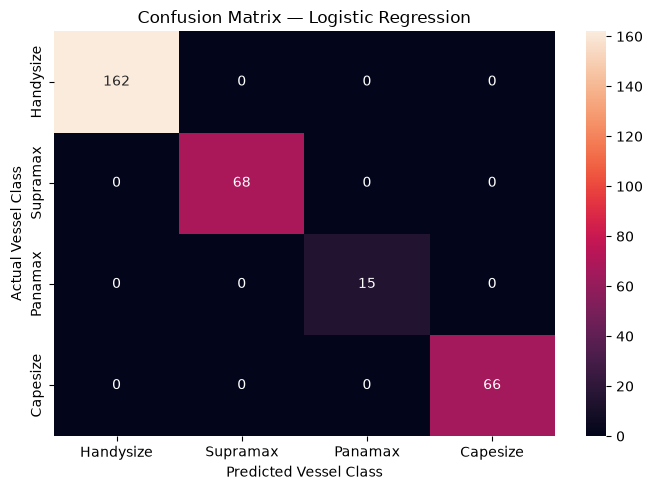

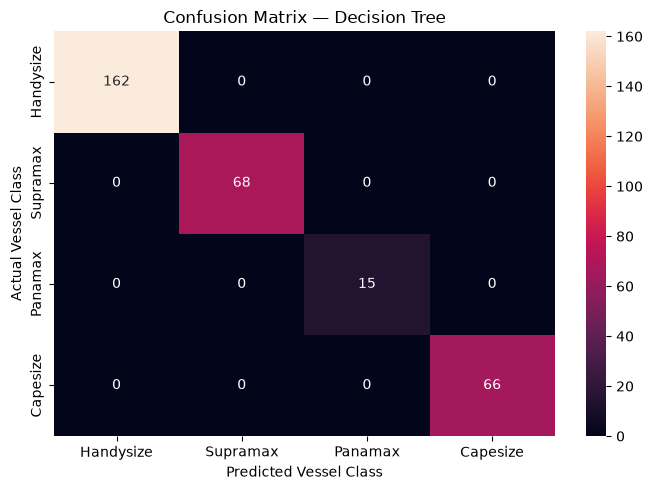

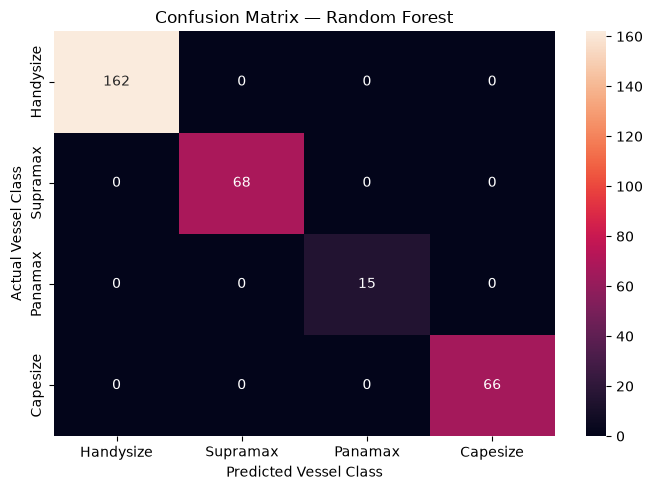

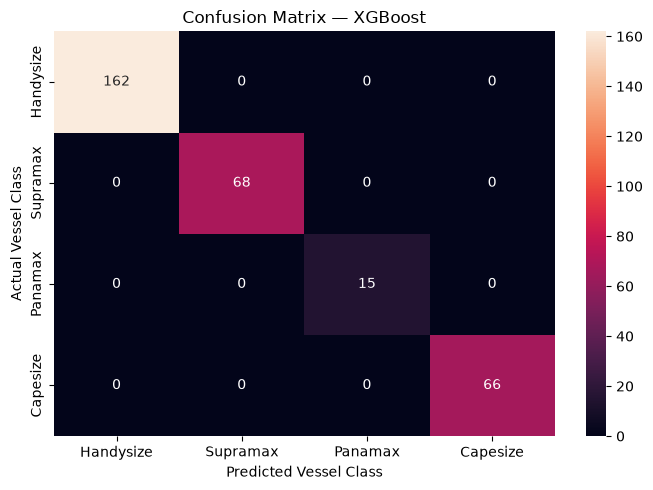


BEST MODEL
Best Model: Logistic Regression
F1-Score: 100.00%


In [48]:
# =========================================================
# MODEL 2 — LEAKAGE-SAFE MODEL EVALUATION
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------------------------------------
# 1. EVALUATE ALL MODELS
# ---------------------------------------------------------

results = []

print("=" * 80)
print("MODEL 2 — LEAKAGE-SAFE EVALUATION")
print("=" * 80)

for model_name, model in trained_models.items():

    # XGBoost was trained with encoded labels
    if model_name == "XGBoost":

        y_pred_encoded = model.predict(X_test)

        # Convert numeric predictions back to vessel classes
        y_pred = label_encoder.inverse_transform(
            y_pred_encoded.astype(int)
        )

    else:

        y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print(f"\n{'-' * 80}")
    print(f"{model_name}")
    print(f"{'-' * 80}")

    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall   : {recall * 100:.2f}%")
    print(f"F1-Score : {f1 * 100:.2f}%")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


# ---------------------------------------------------------
# 2. CREATE MODEL COMPARISON TABLE
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
)


# ---------------------------------------------------------
# 3. CONFUSION MATRICES
# ---------------------------------------------------------

class_order = [
    "Handysize",
    "Supramax",
    "Panamax",
    "Capesize"
]

for model_name, model in trained_models.items():

    if model_name == "XGBoost":

        y_pred_encoded = model.predict(X_test)

        y_pred = label_encoder.inverse_transform(
            y_pred_encoded.astype(int)
        )

    else:

        y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_order
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_order,
        yticklabels=class_order
    )

    plt.title(
        f"Confusion Matrix — {model_name}"
    )

    plt.xlabel("Predicted Vessel Class")
    plt.ylabel("Actual Vessel Class")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 4. BEST MODEL
# ---------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Best Model:", best_model_name)

print(
    f"F1-Score: "
    f"{results_df.iloc[0]['F1-Score'] * 100:.2f}%"
)
